# Define constants

In [1]:
import librosa
from os import path

FEATURES_PATH = path.normpath("../../validations/")
MODEL_SAVE_PATH = path.normpath("../../models/model-bn-c64-c128-c256-c256-d256.keras")

# Least audio duration
AUDIO_MIN_DURATION = 2 # seconds
AUDIO_SAMPLE_RATE = 48_000

# How many frames to skip in each samples
CQT_HOP_LENGTH = 512

# Bin numbers based on octaves for input
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36

# Frame size for input uses the least frames
CQT_FEATURE_FRAMES = round(AUDIO_MIN_DURATION * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)

# Starts from note
CQT_FMIN = librosa.note_to_hz('C1')

# Onset detection parameters
ONSET_PARAMETERS = {
  "delta": 0.07,
  "pre_max": 30,
  "post_max": 1, # 0, must be positive in librosa
  "pre_avg": 100,
  "post_avg": 100,
  "wait": 30,
}

# Setup

In [2]:
import tensorflow as tf

model = tf.keras.models.load_model(MODEL_SAVE_PATH)

print("Model loaded successfully.")

VALIDATION_DATASETS = [
    "sustain_delay",
    "no_sustain_no_delay",
    "sustain_no_delay",
    # "major_only",
]

2026-05-14 23:17:19.401853: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-14 23:17:19.401902: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-14 23:17:19.403358: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-14 23:17:19.410090: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-14 23:17:20.298616: W tensorflow/compiler/tf2

Model loaded successfully.


# Function definitions

In [3]:
import gc

import librosa
import mir_eval
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import classification_report

MODEL_LABELS = [
    'A#_diminished_4', 'A#_major_4', 'A#_minor_4',
    'A_diminished_4', 'A_major_4', 'A_minor_4',
    'B_diminished_4', 'B_major_4', 'B_minor_4',
    'C#_diminished_4', 'C#_major_4', 'C#_minor_4',
    'C_diminished_4', 'C_major_4', 'C_minor_4',
    'D#_diminished_4', 'D#_major_4', 'D#_minor_4',
    'D_diminished_4', 'D_major_4', 'D_minor_4',
    'E_diminished_4', 'E_major_4', 'E_minor_4',
    'F#_diminished_4', 'F#_major_4', 'F#_minor_4',
    'F_diminished_4', 'F_major_4', 'F_minor_4',
    'G#_diminished_4', 'G#_major_4', 'G#_minor_4',
    'G_diminished_4', 'G_major_4', 'G_minor_4',
]

if model.output_shape[-1] != len(MODEL_LABELS):
    raise ValueError(
        f"Model output size {model.output_shape[-1]} does not match the expected ",
        f"number of class labels {len(MODEL_LABELS)}.",
    )

MIR_EVAL_QUALITY_MAP = {
    'major': 'maj',
    'maj': 'maj',
    'minor': 'min',
    'min': 'min',
    'diminished': 'dim',
    'dim': 'dim',
    'augmented': 'aug',
    'aug': 'aug',
    'N': mir_eval.chord.NO_CHORD,
    'n': mir_eval.chord.NO_CHORD,
    'no_chord': mir_eval.chord.NO_CHORD,
    'no-chord': mir_eval.chord.NO_CHORD,
}

def target_npz_path(dataset_name):
    return path.join(FEATURES_PATH, f"{dataset_name}.npz")

def load_validation_npz(dataset_name):
    npz_path = target_npz_path(dataset_name)
    return np.load(npz_path, allow_pickle=True)

def normalize_chord_label(chord_label):
    if chord_label is None:
        return mir_eval.chord.NO_CHORD

    chord_label = str(chord_label).strip()
    if chord_label in {mir_eval.chord.NO_CHORD, 'N', 'n'}:
        return mir_eval.chord.NO_CHORD

    if ':' in chord_label and '_' not in chord_label:
        root, quality = chord_label.split(':', 1)
        normalized_quality = MIR_EVAL_QUALITY_MAP.get(quality.lower(), quality.lower())
        if normalized_quality == mir_eval.chord.NO_CHORD:
            return mir_eval.chord.NO_CHORD
        return f"{root}:{normalized_quality}"

    parts = chord_label.split('_')
    if len(parts) >= 2:
        root = parts[0]
        quality = '_'.join(parts[1:-1]) if len(parts) > 2 else parts[1]
        normalized_quality = MIR_EVAL_QUALITY_MAP.get(quality.lower(), quality.lower())
        if normalized_quality == mir_eval.chord.NO_CHORD:
            return mir_eval.chord.NO_CHORD
        return f"{root}:{normalized_quality}"

    return chord_label

def annotation_to_interval_and_label(annotation):
    if isinstance(annotation, dict):
        start_time = float(annotation['start'])
        end_time = float(annotation['end'])
        chord_label = annotation.get('chord', annotation.get('label', mir_eval.chord.NO_CHORD))
    elif isinstance(annotation, (list, tuple)) and len(annotation) >= 3:
        start_time, end_time, chord_label = annotation[:3]
    else:
        raise TypeError(f'Unsupported annotation format: {type(annotation)!r}')

    return (float(start_time), float(end_time)), normalize_chord_label(chord_label)

def annotations_to_mir_eval(annotations):
    intervals = []
    labels = []

    for annotation in annotations:
        interval, label = annotation_to_interval_and_label(annotation)
        intervals.append(interval)
        labels.append(label)

    intervals = np.asarray(intervals, dtype=float)
    labels = list(labels)

    if intervals.size == 0:
        return intervals.reshape(0, 2), labels

    order = np.argsort(intervals[:, 0], kind='mergesort')
    intervals = intervals[order]
    labels = [labels[index] for index in order]

    merged_intervals = [intervals[0].tolist()]
    merged_labels = [labels[0]]

    for interval, label in zip(intervals[1:], labels[1:]):
        if label == merged_labels[-1] and np.isclose(interval[0], merged_intervals[-1][1]):
            merged_intervals[-1][1] = float(interval[1])
        else:
            merged_intervals.append(interval.tolist())
            merged_labels.append(label)

    return np.asarray(merged_intervals, dtype=float), merged_labels

def stretch_features_to_frames(feature_array, target_frames=CQT_FEATURE_FRAMES):
    feature_array = np.asarray(feature_array)

    if feature_array.ndim == 2:
        source_frames = feature_array.shape[1]
        if source_frames == target_frames:
            return feature_array.astype(np.float32, copy=False)
        if source_frames == 1:
            return np.repeat(feature_array, target_frames, axis=1).astype(np.float32, copy=False)

        source_positions = np.linspace(0.0, 1.0, source_frames)
        target_positions = np.linspace(0.0, 1.0, target_frames)
        stretched_rows = [
            np.interp(target_positions, source_positions, row)
            for row in feature_array
        ]
        return np.asarray(stretched_rows, dtype=np.float32)

    if feature_array.ndim == 3:
        return np.stack(
            [stretch_features_to_frames(sample, target_frames) for sample in feature_array],
            axis=0,
        )

    raise ValueError(f"Expected a 2D or 3D feature array, got shape {feature_array.shape}")

def detect_onsets_from_cqt(sample_cqt, parameters):
    onset_envelope = librosa.onset.onset_strength(
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        S=sample_cqt,
    )

    onset_frames = librosa.onset.onset_detect(
        onset_envelope=onset_envelope,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        backtrack=False,
        **parameters,
    )

    onset_times = librosa.frames_to_time(
        onset_frames,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
    )

    return onset_frames, onset_times, onset_envelope

def classify_chord_window(window_cqt):
    window_input = window_cqt[np.newaxis, ..., np.newaxis].astype(np.float32, copy=False)
    predictions = model.predict(window_input, verbose=0)[0]
    predicted_index = int(np.argmax(predictions))
    predicted_label = MODEL_LABELS[predicted_index]
    return predicted_label, predicted_index, predictions

def build_estimated_annotations_for_sample(sample_cqt, parameters, dataset_name, sample_index):
    onset_frames, onset_times, onset_envelope = detect_onsets_from_cqt(sample_cqt, parameters)
    onset_frames = np.asarray(onset_frames, dtype=int)
    onset_times = np.asarray(onset_times, dtype=float)
    sample_frames = int(sample_cqt.shape[1])
    sample_duration = float(librosa.frames_to_time(sample_frames, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH))

    estimated_intervals = []
    estimated_labels = []
    prediction_rows = []

    if onset_frames.size == 0:
        window_end_frame = min(sample_frames, CQT_FEATURE_FRAMES)
        window_cqt = sample_cqt[:, :window_end_frame]
        stretched_window = stretch_features_to_frames(window_cqt, CQT_FEATURE_FRAMES)
        raw_label, predicted_index, probabilities = classify_chord_window(stretched_window)
        estimated_intervals.append([0.0, sample_duration])
        estimated_labels.append(normalize_chord_label(raw_label))
        prediction_rows.append({
            'dataset': dataset_name,
            'sample_index': sample_index,
            'segment_index': 0,
            'onset_frame': 0,
            'onset_time': 0.0,
            'window_start_frame': 0,
            'window_end_frame': window_end_frame,
            'interval_end_frame': sample_frames,
            'interval_end_time': sample_duration,
            'window_frames': int(window_cqt.shape[1]),
            'window_truncated_by_next_onset': False,
            'raw_prediction': raw_label,
            'prediction': normalize_chord_label(raw_label),
            'prediction_index': predicted_index,
            'confidence': float(probabilities[predicted_index]),
        })
    else:
        for onset_index, onset_frame in enumerate(onset_frames):
            next_onset_frame = int(onset_frames[onset_index + 1]) if onset_index + 1 < onset_frames.size else sample_frames
            window_end_frame = min(int(onset_frame) + CQT_FEATURE_FRAMES, next_onset_frame)
            window_cqt = sample_cqt[:, int(onset_frame):window_end_frame]

            if window_cqt.shape[1] == 0:
                continue

            stretched_window = stretch_features_to_frames(window_cqt, CQT_FEATURE_FRAMES)
            raw_label, predicted_index, probabilities = classify_chord_window(stretched_window)
            predicted_label = normalize_chord_label(raw_label)

            start_time = float(librosa.frames_to_time(int(onset_frame), sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH))
            end_time = float(librosa.frames_to_time(next_onset_frame, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH))

            estimated_intervals.append([start_time, end_time])
            estimated_labels.append(predicted_label)
            prediction_rows.append({
                'dataset': dataset_name,
                'sample_index': sample_index,
                'segment_index': onset_index,
                'onset_frame': int(onset_frame),
                'onset_time': start_time,
                'window_start_frame': int(onset_frame),
                'window_end_frame': window_end_frame,
                'interval_end_frame': next_onset_frame,
                'interval_end_time': end_time,
                'window_frames': int(window_cqt.shape[1]),
                'window_truncated_by_next_onset': bool(next_onset_frame < int(onset_frame) + CQT_FEATURE_FRAMES),
                'raw_prediction': raw_label,
                'prediction': predicted_label,
                'prediction_index': predicted_index,
                'confidence': float(probabilities[predicted_index]),
            })

    estimated_intervals = np.asarray(estimated_intervals, dtype=float)
    estimated_labels = list(estimated_labels)

    return {
        'dataset': dataset_name,
        'sample_index': sample_index,
        'sample_duration': sample_duration,
        'sample_frames': sample_frames,
        'onset_frames': onset_frames,
        'onset_times': onset_times,
        'onset_envelope': onset_envelope,
        'estimated_intervals': estimated_intervals,
        'estimated_labels': estimated_labels,
        'predictions': pd.DataFrame(prediction_rows),
        'num_detected_onsets': int(onset_frames.size),
        'num_segments': int(len(estimated_labels)),
        'num_truncated_windows': int(sum(row['window_truncated_by_next_onset'] for row in prediction_rows)),
        'average_window_frames': float(np.mean([row['window_frames'] for row in prediction_rows])) if prediction_rows else 0.0,
    }

def evaluate_sample_annotations(reference_annotations, estimated_intervals, estimated_labels, dataset_name, sample_index):
    reference_intervals, reference_labels = annotations_to_mir_eval(reference_annotations)

    if reference_intervals.size == 0:
        raise ValueError(f'No reference annotations available for {dataset_name} sample {sample_index}.')

    reference_start = float(reference_intervals[0, 0])
    reference_end = float(reference_intervals[-1, 1])

    adjusted_reference_intervals, adjusted_reference_labels = mir_eval.util.adjust_intervals(
        reference_intervals,
        reference_labels,
        t_min=reference_start,
        t_max=reference_end,
        start_label=mir_eval.chord.NO_CHORD,
        end_label=mir_eval.chord.NO_CHORD,
    )

    if estimated_intervals.size == 0:
        estimated_intervals = np.asarray([[reference_start, reference_end]], dtype=float)
        estimated_labels = [mir_eval.chord.NO_CHORD]

    adjusted_estimated_intervals, adjusted_estimated_labels = mir_eval.util.adjust_intervals(
        np.asarray(estimated_intervals, dtype=float),
        list(estimated_labels),
        t_min=reference_start,
        t_max=reference_end,
        start_label=mir_eval.chord.NO_CHORD,
        end_label=mir_eval.chord.NO_CHORD,
    )

    scores = mir_eval.chord.evaluate(
        adjusted_reference_intervals,
        adjusted_reference_labels,
        adjusted_estimated_intervals,
        adjusted_estimated_labels,
    )

    merged_intervals, merged_reference_labels, merged_estimated_labels = mir_eval.util.merge_labeled_intervals(
        adjusted_reference_intervals,
        adjusted_reference_labels,
        adjusted_estimated_intervals,
        adjusted_estimated_labels,
    )

    merged_durations = mir_eval.util.intervals_to_durations(merged_intervals)

    class_labels = sorted(set(merged_reference_labels).union(set(merged_estimated_labels)))
    class_report = classification_report(
        merged_reference_labels,
        merged_estimated_labels,
        labels=class_labels,
        sample_weight=merged_durations,
        zero_division=0,
        output_dict=True,
    )

    return {
        'reference_intervals': adjusted_reference_intervals,
        'reference_labels': list(adjusted_reference_labels),
        'estimated_intervals': adjusted_estimated_intervals,
        'estimated_labels': list(adjusted_estimated_labels),
        'scores': scores,
        'merged_intervals': merged_intervals,
        'merged_reference_labels': list(merged_reference_labels),
        'merged_estimated_labels': list(merged_estimated_labels),
        'merged_durations': merged_durations,
        'class_report': pd.DataFrame(class_report).T,
    }

def evaluate_dataset(dataset_name, parameters):
    with load_validation_npz(dataset_name) as data:
        features = data['features']
        labels = data['labels']
        annotations = data['annotations']

        sample_rows = []
        prediction_frames = []
        score_rows = []
        merged_reference_labels = []
        merged_estimated_labels = []
        merged_durations = []
        total_duration = 0.0

        for sample_index, sample_cqt in enumerate(features):
            sample_prediction = build_estimated_annotations_for_sample(
                sample_cqt,
                parameters,
                dataset_name,
                sample_index,
            )

            sample_evaluation = evaluate_sample_annotations(
                annotations[sample_index],
                sample_prediction['estimated_intervals'],
                sample_prediction['estimated_labels'],
                dataset_name,
                sample_index,
            )

            score_row = {
                'dataset': dataset_name,
                'sample_index': sample_index,
                'sample_duration': sample_prediction['sample_duration'],
                'num_detected_onsets': sample_prediction['num_detected_onsets'],
                'num_segments': sample_prediction['num_segments'],
                'num_truncated_windows': sample_prediction['num_truncated_windows'],
                'average_window_frames': sample_prediction['average_window_frames'],
                **sample_evaluation['scores'],
            }

            sample_rows.append(score_row)
            score_rows.append(score_row)
            total_duration += sample_prediction['sample_duration']

            if not sample_prediction['predictions'].empty:
                prediction_frames.append(sample_prediction['predictions'])

            merged_reference_labels.extend(sample_evaluation['merged_reference_labels'])
            merged_estimated_labels.extend(sample_evaluation['merged_estimated_labels'])
            merged_durations.extend(sample_evaluation['merged_durations'])

        sample_summary_df = pd.DataFrame(sample_rows)

        if prediction_frames:
            predictions_df = pd.concat(prediction_frames, ignore_index=True)
        else:
            predictions_df = pd.DataFrame()

        overall_scores = {}
        score_keys = [key for key in score_rows[0].keys() if key not in {
            'dataset',
            'sample_index',
            'sample_duration',
            'num_detected_onsets',
            'num_segments',
            'num_truncated_windows',
            'average_window_frames',
        }] if score_rows else []

        for key in score_keys:
            weighted_sum = 0.0
            weight_sum = 0.0
            for row in score_rows:
                if key in row:
                    weighted_sum += float(row[key]) * float(row['sample_duration'])
                    weight_sum += float(row['sample_duration'])
            overall_scores[key] = weighted_sum / weight_sum if weight_sum else float('nan')

        overall_scores_df = pd.DataFrame([{'dataset': dataset_name, **overall_scores, 'total_duration': total_duration}])

        class_report_df = pd.DataFrame()
        if merged_reference_labels:
            class_labels = sorted(set(merged_reference_labels).union(set(merged_estimated_labels)))
            class_report_df = pd.DataFrame(
                classification_report(
                    merged_reference_labels,
                    merged_estimated_labels,
                    labels=class_labels,
                    sample_weight=np.asarray(merged_durations, dtype=float),
                    zero_division=0,
                    output_dict=True,
                )
            ).T

        return {
            'dataset_name': dataset_name,
            'features': features,
            'labels': labels,
            'annotations': annotations,
            'sample_summary': sample_summary_df,
            'predictions': predictions_df,
            'overall_scores': overall_scores_df,
            'class_report': class_report_df,
            'sample_scores': pd.DataFrame(score_rows),
        }

def evaluate_validation_datasets(dataset_names, parameters):
    return {
        dataset_name: evaluate_dataset(dataset_name, parameters)
        for dataset_name in dataset_names
    }

def summarize_overall_results(dataset_results):
    summary_rows = []
    class_report_rows = []
    prediction_frames = []
    sample_score_frames = []

    for dataset_name, dataset_result in dataset_results.items():
        summary_rows.append(dataset_result['overall_scores'].iloc[0].to_dict())
        if not dataset_result['class_report'].empty:
            class_report = dataset_result['class_report'].copy()
            class_report['dataset'] = dataset_name
            class_report['label'] = class_report.index
            class_report_rows.append(class_report.reset_index(drop=True))
        if not dataset_result['predictions'].empty:
            prediction_frames.append(dataset_result['predictions'])
        sample_score_frames.append(dataset_result['sample_scores'])

    overall_summary_df = pd.DataFrame(summary_rows)
    per_class_report_df = pd.concat(class_report_rows, ignore_index=True) if class_report_rows else pd.DataFrame()
    all_predictions_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
    all_sample_scores_df = pd.concat(sample_score_frames, ignore_index=True) if sample_score_frames else pd.DataFrame()

    return {
        'overall_summary': overall_summary_df,
        'per_class_report': per_class_report_df,
        'all_predictions': all_predictions_df,
        'all_sample_scores': all_sample_scores_df,
    }

In [4]:
def plot_confusion_matrix(confusion_df, title):
    figure, axis = plt.subplots(figsize=(10, 10))
    sns.heatmap(
        confusion_df,
        annot=True,
        annot_kws={'size': 8},
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel('Predicted label')
    axis.set_ylabel('True label')
    return figure

gc.collect()

0

# Evaluations

In [5]:
dataset_results = evaluate_validation_datasets(VALIDATION_DATASETS, ONSET_PARAMETERS)
result_tables = summarize_overall_results(dataset_results)

print("Completed evaluation for datasets:", ", ".join(dataset_results.keys()))

2026-05-14 23:17:27.442094: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-14 23:17:27.526928: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-14 23:17:27.968228: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Completed evaluation for datasets: sustain_delay, no_sustain_no_delay, sustain_no_delay


# Results

In [11]:
overall_summary_df = result_tables['overall_summary'].copy()
per_class_report_df = result_tables['per_class_report'].copy()
all_predictions_df = result_tables['all_predictions'].copy()
all_sample_scores_df = result_tables['all_sample_scores'].copy()

display(overall_summary_df.round(4))
display(all_sample_scores_df.round(4))
display(per_class_report_df.round(4))

# for dataset_name, dataset_result in dataset_results.items():
#     print(f"Dataset: {dataset_name}")
#     display(dataset_result['overall_scores'].round(4))
#     display(dataset_result['sample_summary'].round(4))
#     if not dataset_result['class_report'].empty:
#         display(dataset_result['class_report'].round(4))
#     if not dataset_result['predictions'].empty:
#         display(dataset_result['predictions'].head(25))

,dataset,thirds,thirds_inv,triads,triads_inv,tetrads,tetrads_inv,root,mirex,majmin,majmin_inv,sevenths,sevenths_inv,underseg,overseg,seg,total_duration
0,sustain_delay,0.4080,0.4080,0.3981,0.3981,0.3981,0.3981,0.4421,0.3981,0.3616,0.3616,0.3616,0.3616,0.6381,0.9037,0.6381,375.4987
1,no_sustain_no_delay,0.3050,0.3050,0.2758,0.2758,0.2758,0.2758,0.3342,0.2758,0.2563,0.2563,0.2563,0.2563,0.5579,0.9237,0.5579,561.1733
2,sustain_no_delay,0.5369,0.5369,0.5254,0.5254,0.5254,0.5254,0.5618,0.5254,0.5319,0.5319,0.5319,0.5319,0.6290,0.8734,0.6290,109.5253


,dataset,sample_index,sample_duration,num_detected_onsets,num_segments,num_truncated_windows,average_window_frames,thirds,thirds_inv,triads,...,tetrads_inv,root,mirex,majmin,majmin_inv,sevenths,sevenths_inv,underseg,overseg,seg
0,sustain_delay,0,17.2587,10,10,8,153.0,0.2260,0.2260,0.1949,...,0.1949,0.2629,0.1949,0.2597,0.2597,0.2597,0.2597,0.5876,0.8896,0.5876
1,sustain_delay,1,19.4667,10,10,7,163.7,0.3831,0.3831,0.3130,...,0.3130,0.3831,0.3130,0.3039,0.3039,0.3039,0.3039,0.6055,0.8570,0.6055
2,sustain_delay,2,18.7520,10,10,5,162.0,0.4868,0.4868,0.4868,...,0.4868,0.5418,0.4868,0.4868,0.4868,0.4868,0.4868,0.7345,0.9255,0.7345
3,sustain_delay,3,20.0107,10,10,5,175.0,0.5310,0.5310,0.5310,...,0.5310,0.5310,0.5310,0.4819,0.4819,0.4819,0.4819,0.6508,0.8712,0.6508
4,sustain_delay,4,18.1440,10,10,6,159.3,0.4435,0.4435,0.4435,...,0.4435,0.5380,0.4435,0.3578,0.3578,0.3578,0.3578,0.6712,0.9127,0.6712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,sustain_no_delay,5,10.8053,10,10,10,100.5,0.4720,0.4720,0.3814,...,0.3814,0.6199,0.3814,0.3883,0.3883,0.3883,0.3883,0.6105,0.7943,0.6105
58,sustain_no_delay,6,11.4667,10,10,10,106.6,0.5452,0.5452,0.5363,...,0.5363,0.5452,0.5363,0.6080,0.6080,0.6080,0.6080,0.6480,0.9027,0.6480
59,sustain_no_delay,7,10.4747,10,10,10,97.4,0.5017,0.5017,0.5017,...,0.5017,0.5511,0.5017,0.4564,0.4564,0.4564,0.4564,0.6078,0.8967,0.6078
60,sustain_no_delay,8,10.9760,10,10,10,102.0,0.5627,0.5627,0.5627,...,0.5627,0.5627,0.5627,0.5951,0.5951,0.5951,0.5951,0.6226,0.8947,0.6226


,precision,recall,f1-score,support,dataset,label
0,0.7371,0.4967,0.5935,10.2730,sustain_delay,A#:dim
1,0.3903,0.2319,0.2909,12.2790,sustain_delay,A#:maj
2,0.2062,0.0166,0.0308,16.5320,sustain_delay,A#:min
3,0.8742,0.6628,0.7540,12.2680,sustain_delay,A:dim
4,0.6895,0.3382,0.4538,7.0680,sustain_delay,A:maj
...,...,...,...,...,...,...
111,0.8432,0.6981,0.7638,8.3950,sustain_no_delay,G:min
112,0.0000,0.0000,0.0000,0.0000,sustain_no_delay,N
113,0.5254,0.5254,0.5254,0.5254,sustain_no_delay,accuracy
114,0.5347,0.5039,0.5099,118.4740,sustain_no_delay,macro avg


Classification confusion matrices: sustain_delay


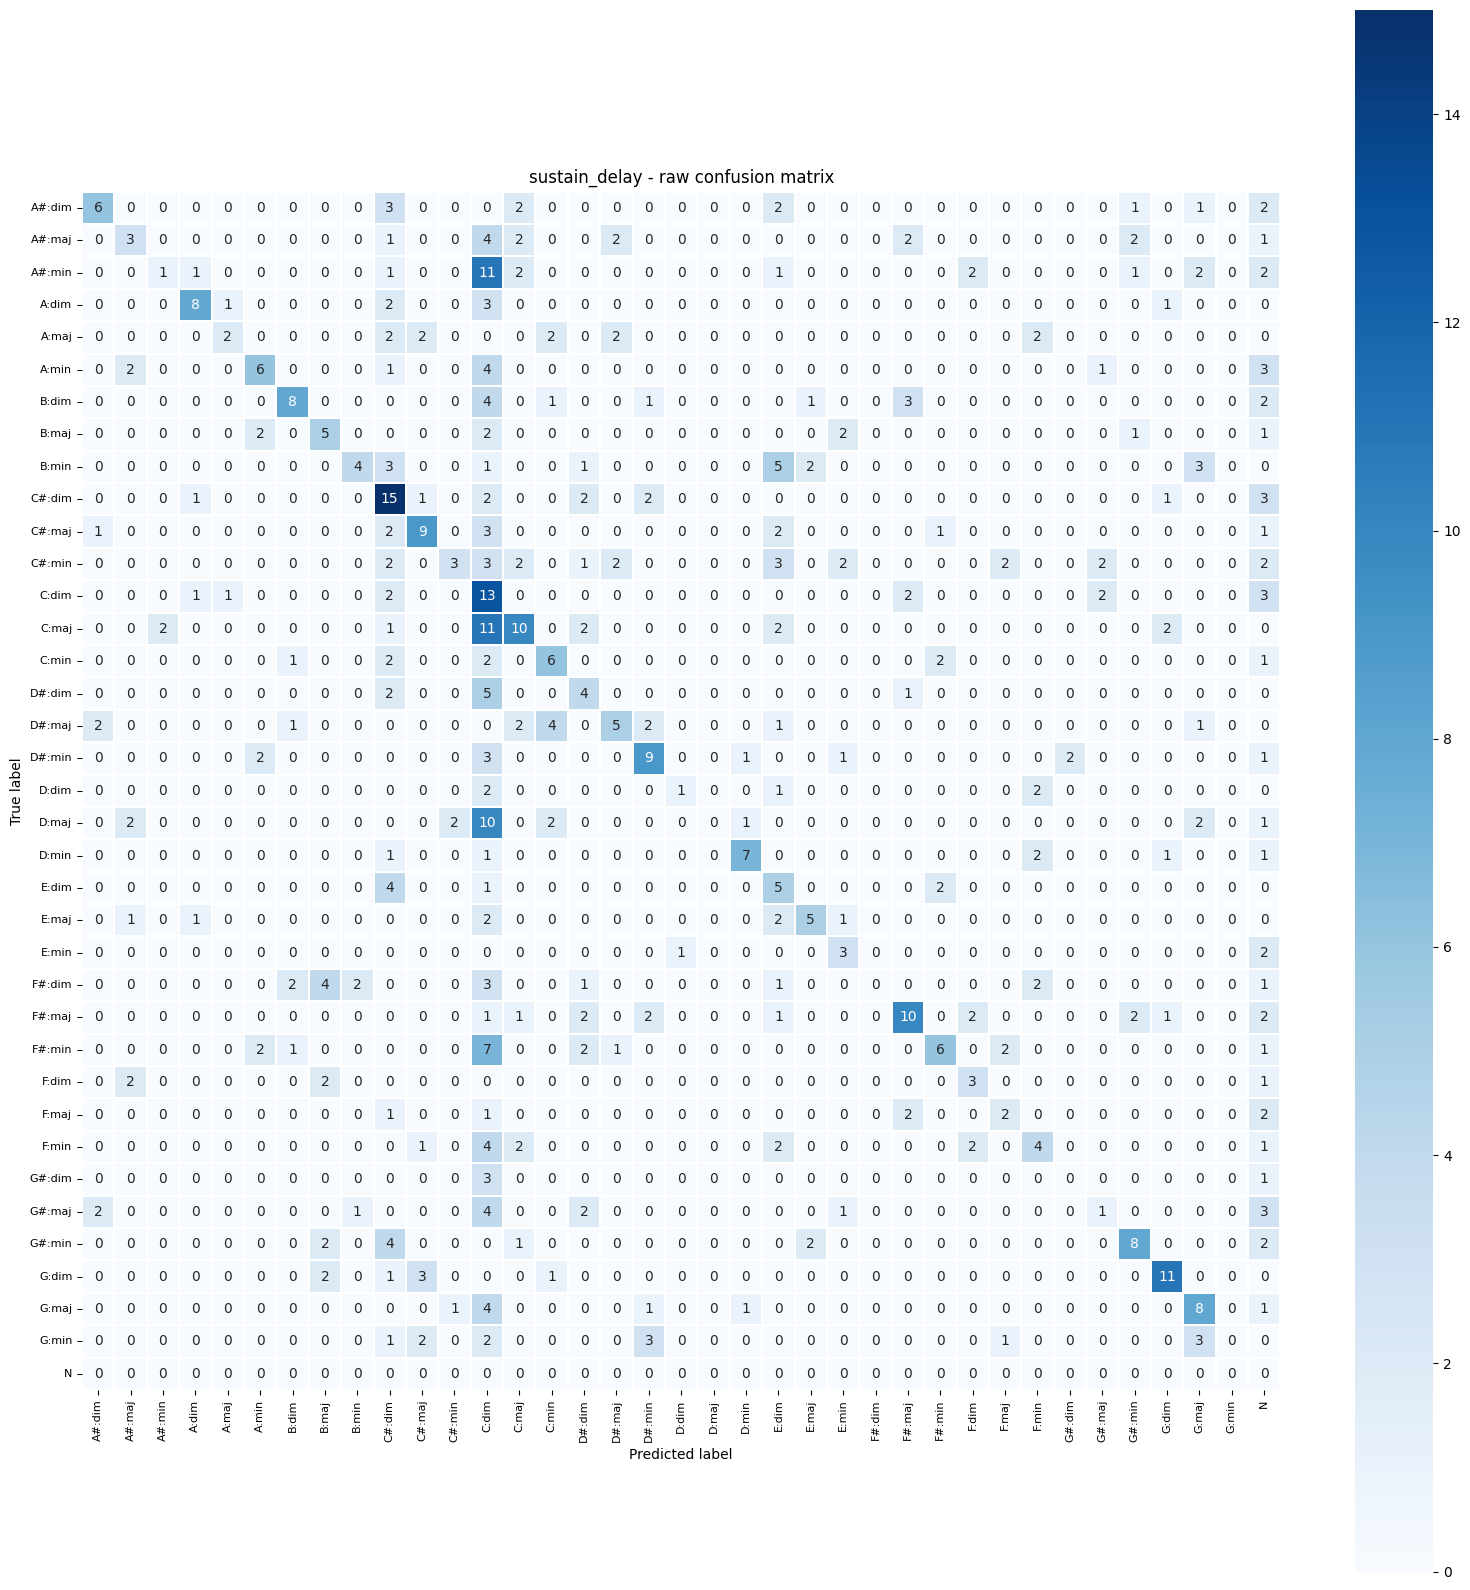

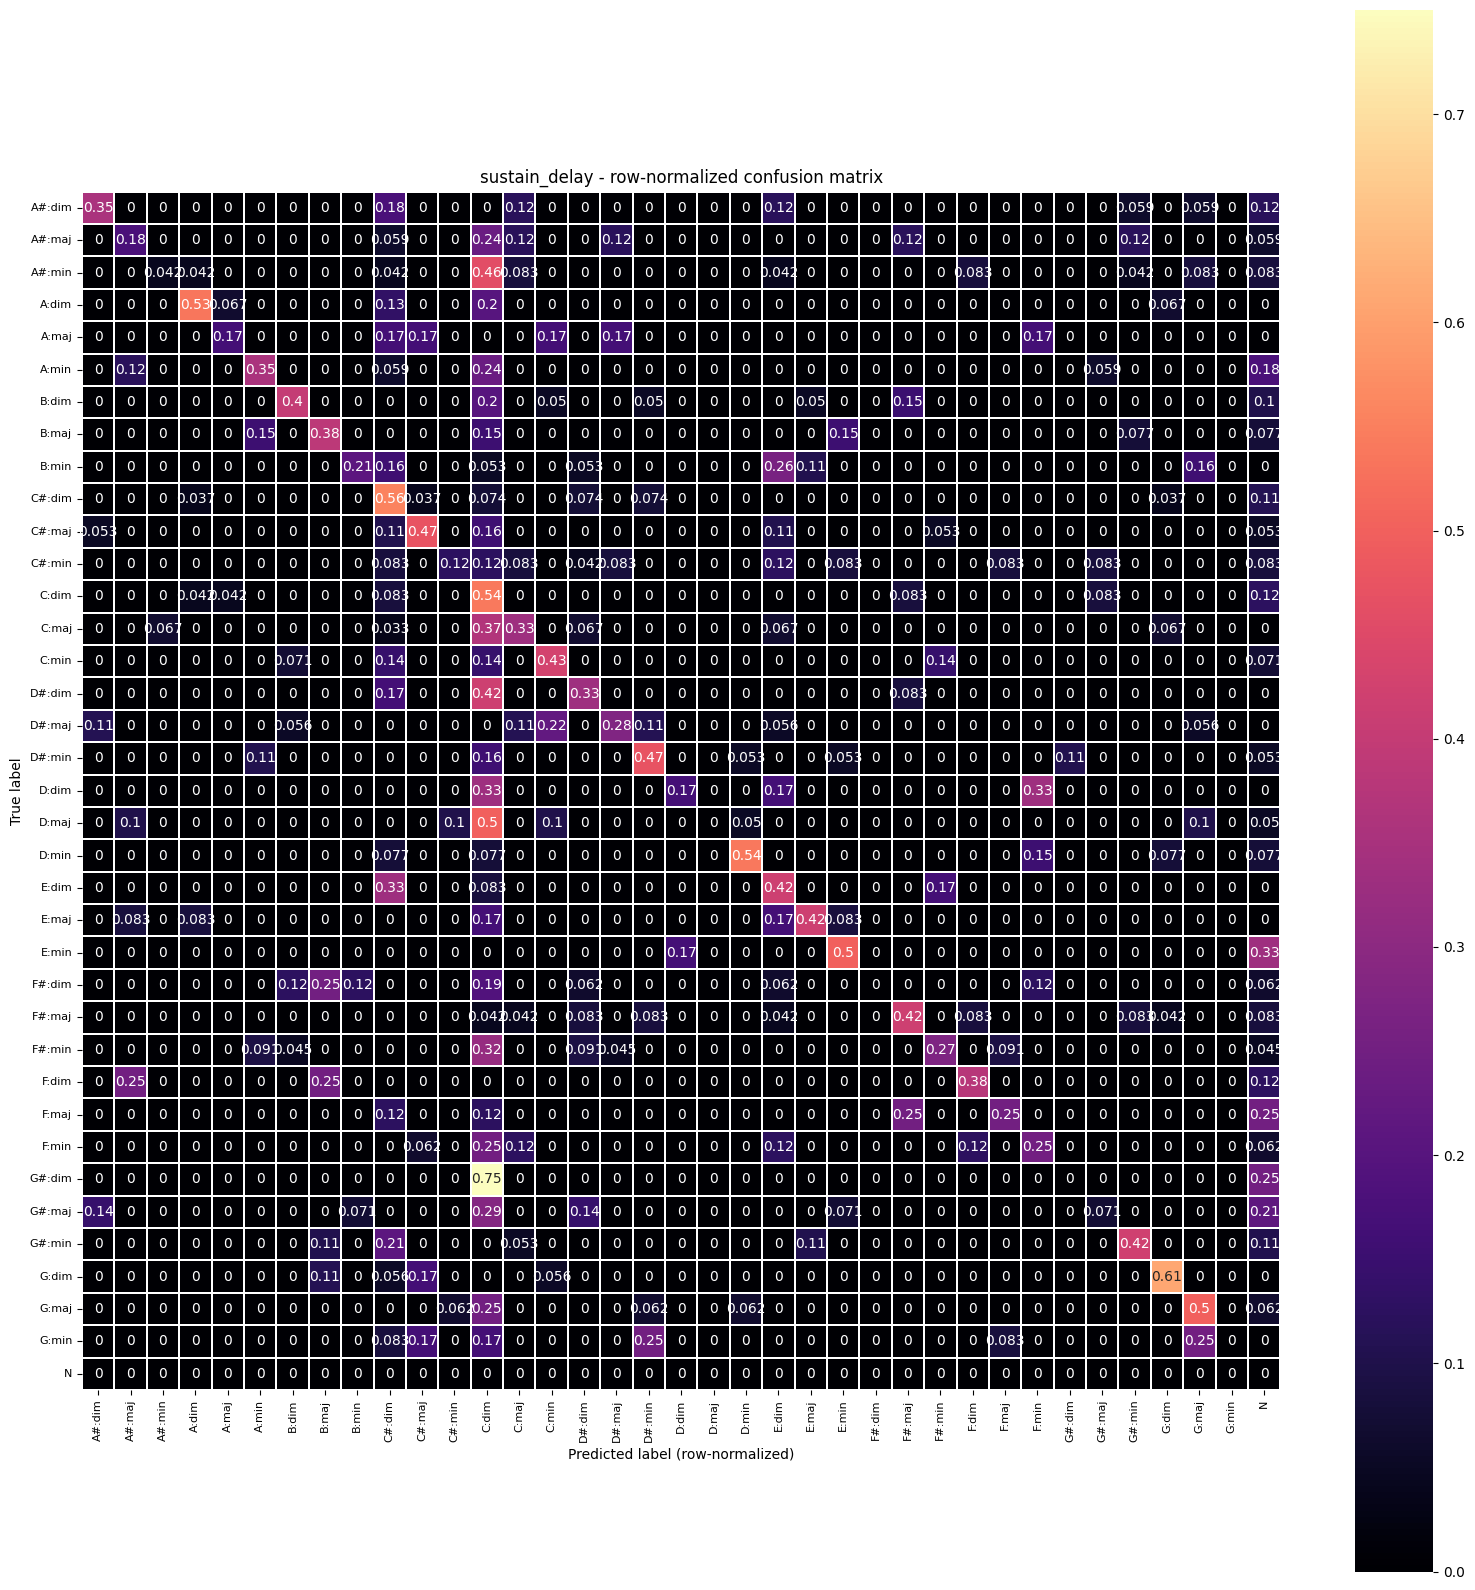

,true_label,predicted_label,count,weighted_duration,row_normalized_rate
15,A#:min,C:dim,11,7.2873,0.4583
84,C:maj,C:dim,11,7.2587,0.3667
114,D:maj,C:dim,10,5.8590,0.5000
153,F#:min,C:dim,7,6.5863,0.3182
50,B:min,E:dim,5,3.8660,0.2632
94,D#:dim,C:dim,5,3.7773,0.4167
36,B:dim,C:dim,4,3.3427,0.2000
33,A:min,C:dim,4,3.1283,0.2353
99,D#:maj,C:min,4,3.0157,0.2222
7,A#:maj,C:dim,4,2.8987,0.2353


Classification confusion matrices: no_sustain_no_delay


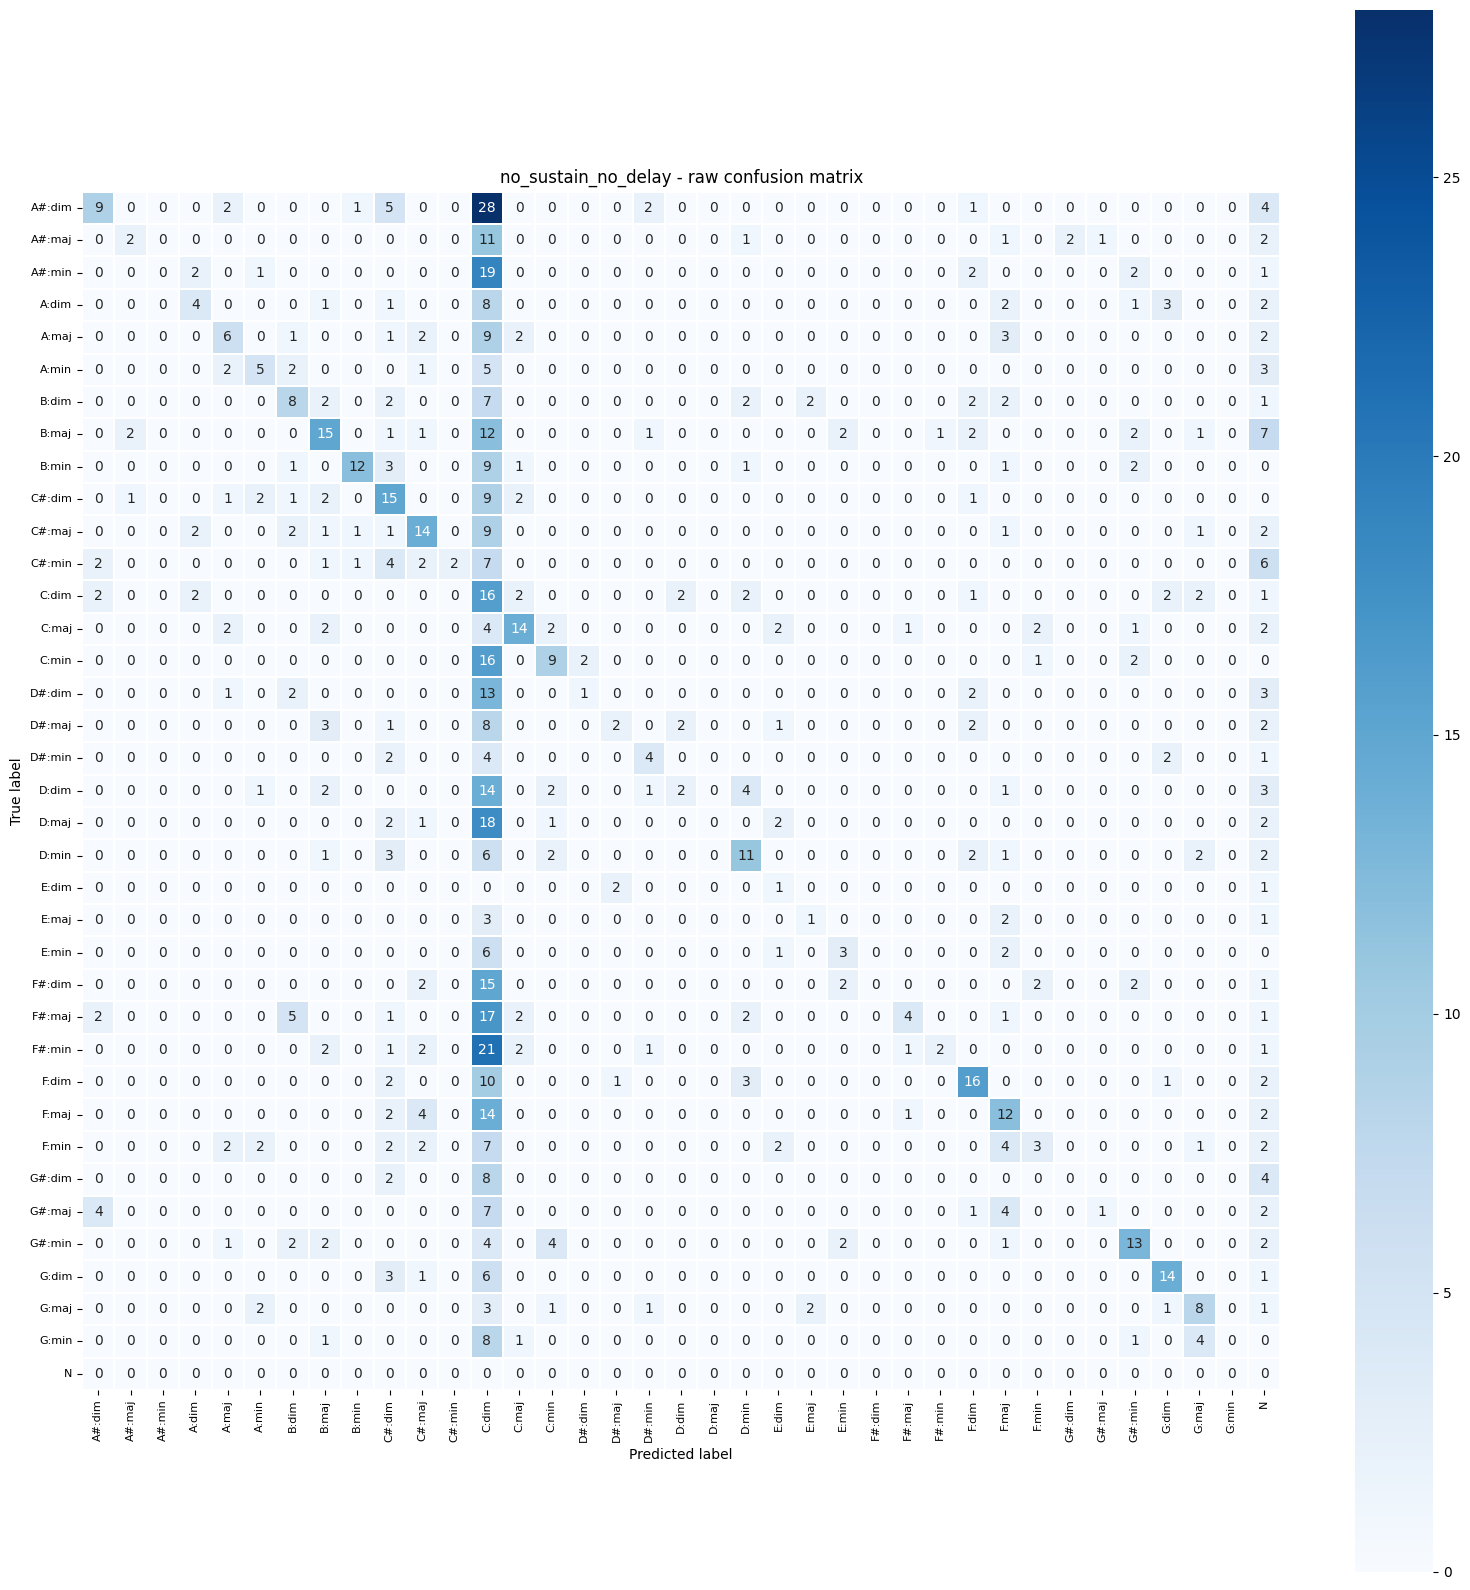

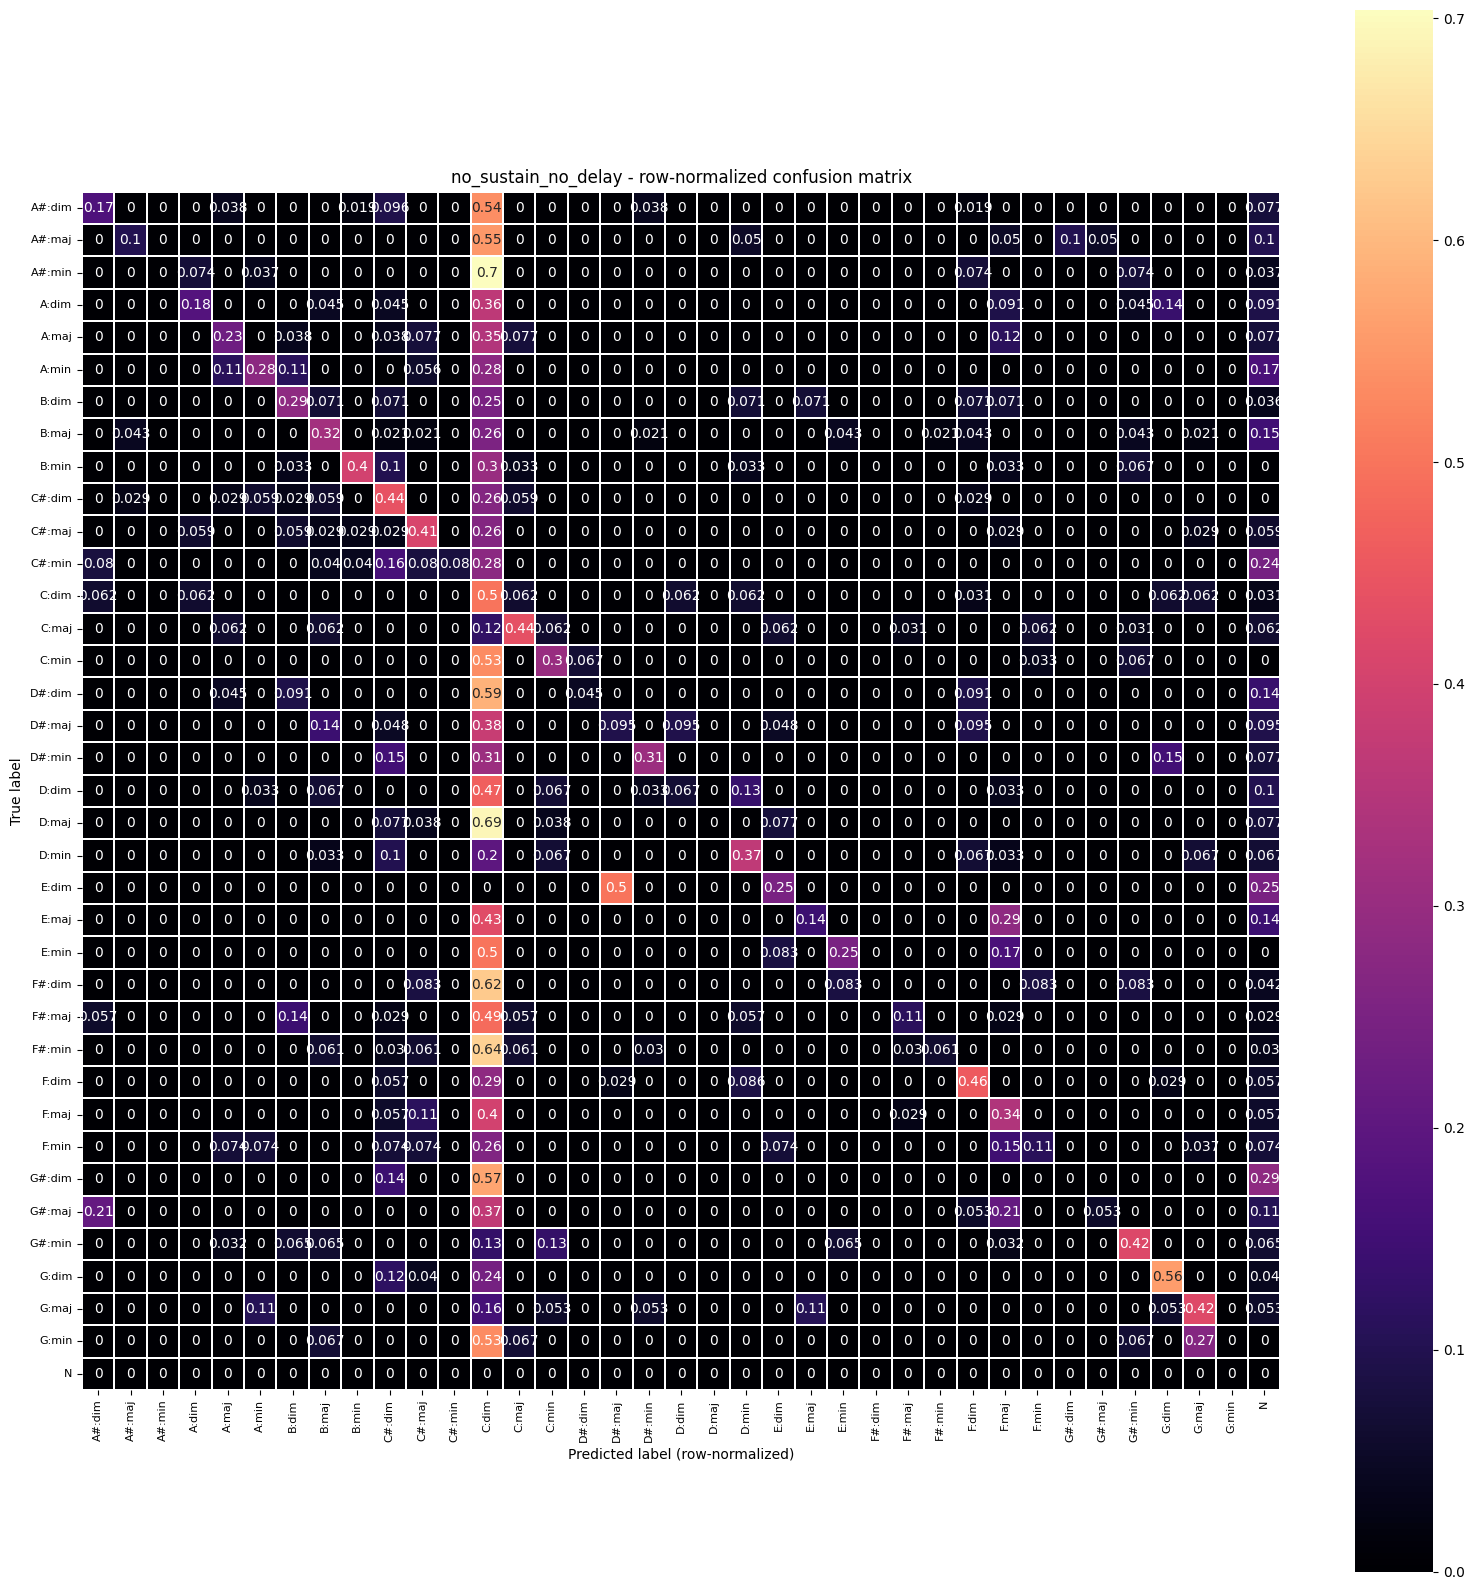

,true_label,predicted_label,count,weighted_duration,row_normalized_rate
3,A#:dim,C:dim,28,19.7760,0.5385
173,F#:min,C:dim,21,14.6323,0.6364
15,A#:min,C:dim,19,12.5960,0.7037
136,D:maj,C:dim,18,11.2713,0.6923
165,F#:maj,C:dim,17,13.2500,0.4857
106,C:min,C:dim,16,9.3423,0.5333
157,F#:dim,C:dim,15,9.5683,0.6250
128,D:dim,C:dim,14,9.1590,0.4667
186,F:maj,C:dim,14,8.5413,0.4000
112,D#:dim,C:dim,13,8.8773,0.5909


Classification confusion matrices: sustain_no_delay


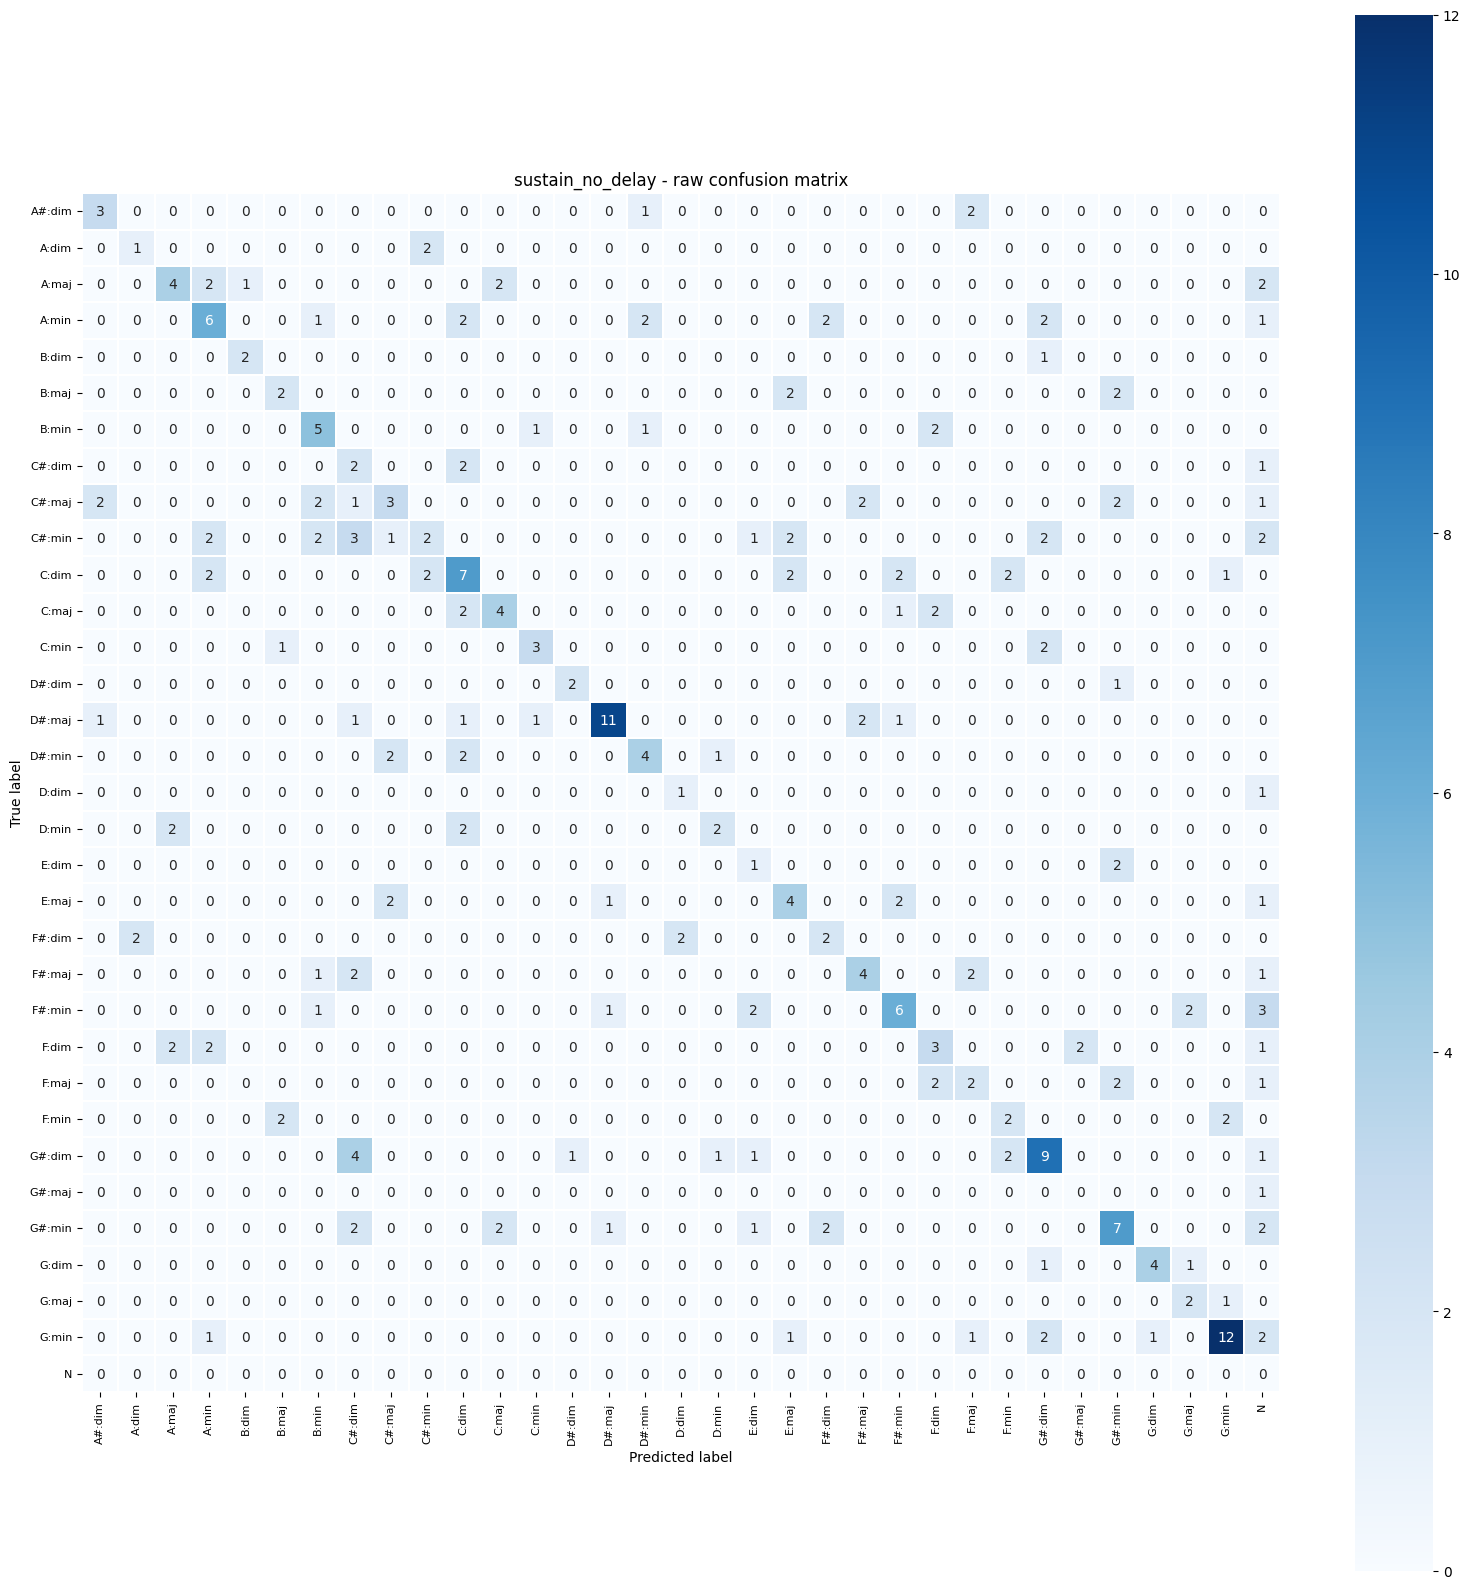

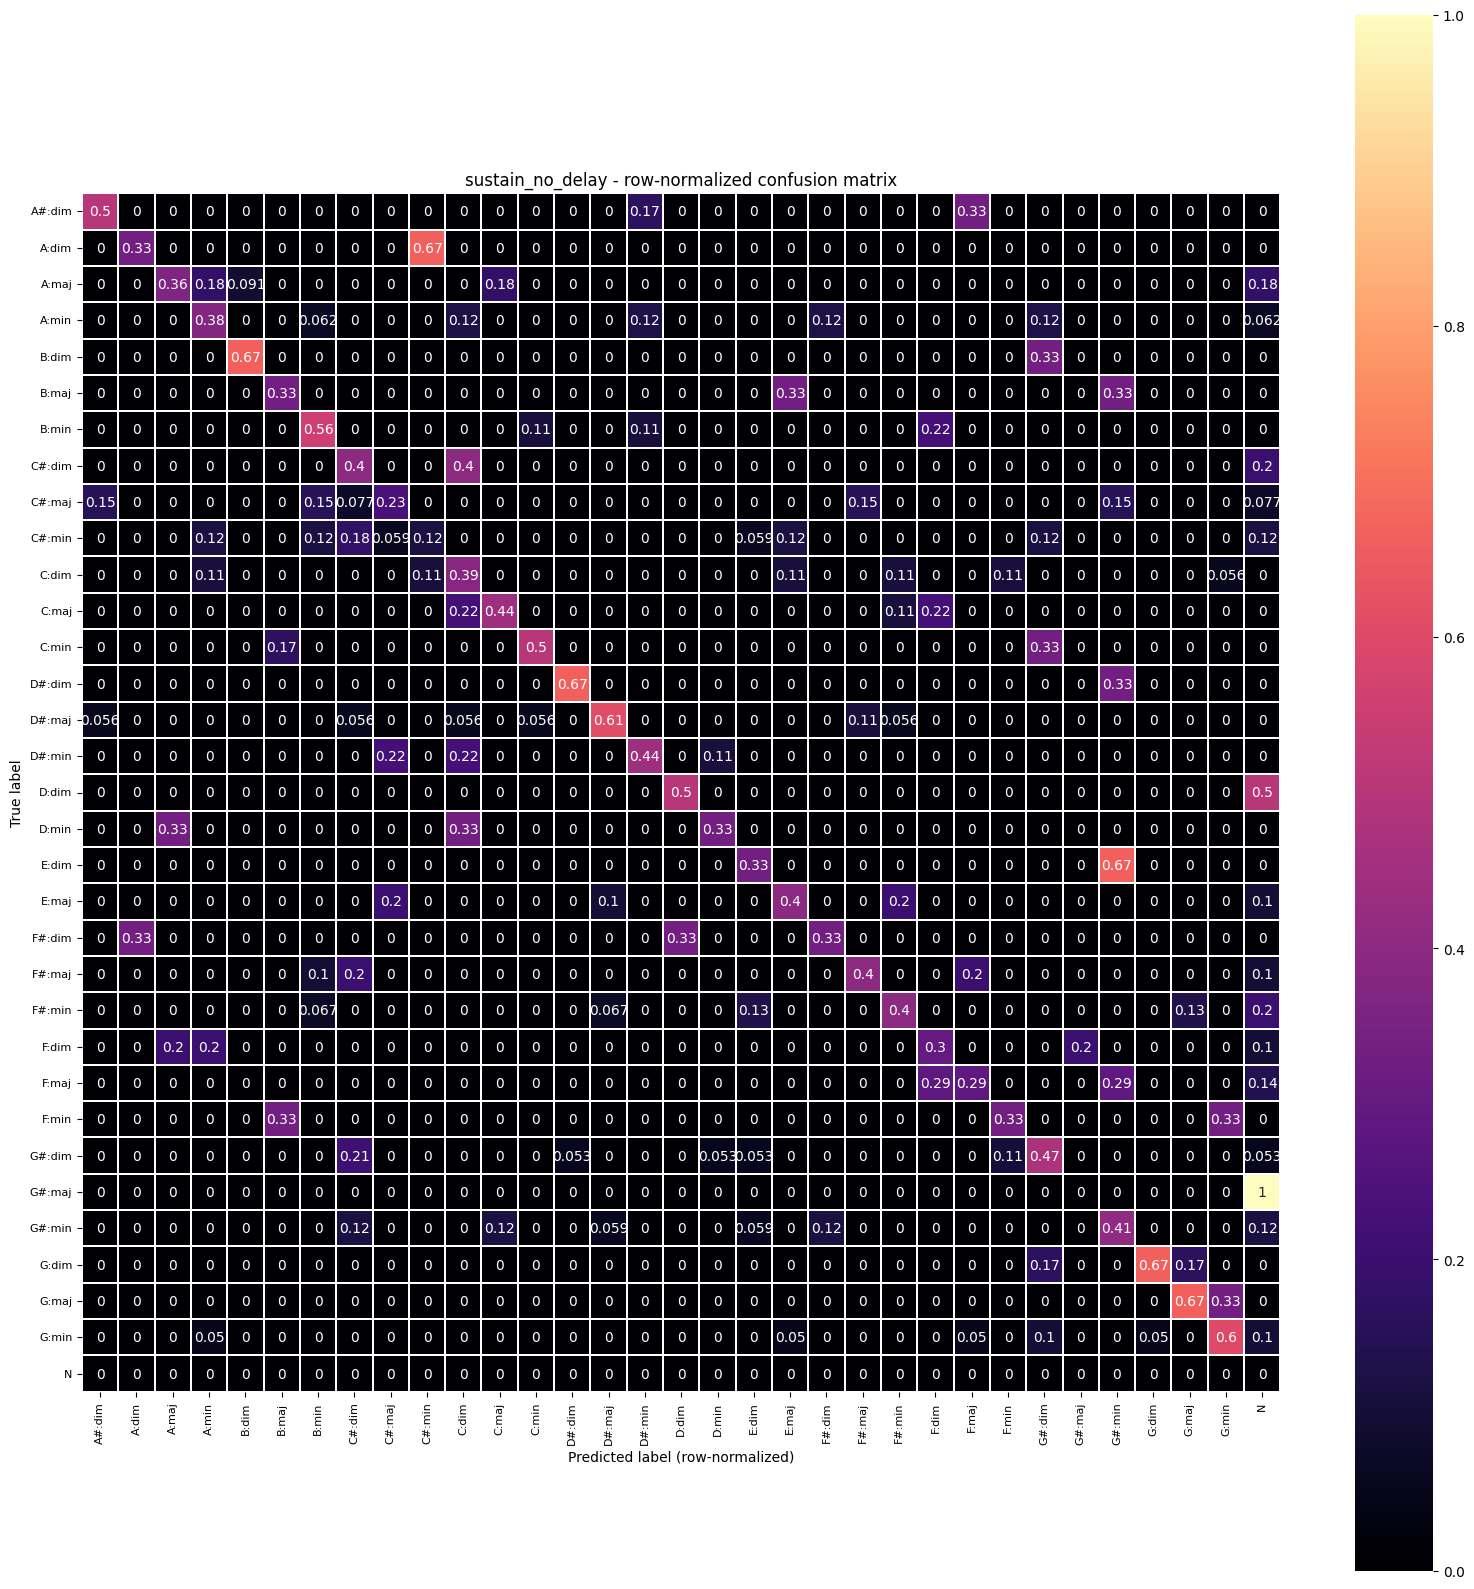

,true_label,predicted_label,count,weighted_duration,row_normalized_rate
84,G#:dim,C#:dim,4,1.7287,0.2105
29,C#:min,C#:dim,3,1.1697,0.1765
74,F#:min,N,3,1.0787,0.2000
51,D#:maj,F#:maj,2,1.1110,0.1111
65,F#:dim,D:dim,2,0.9323,0.3333
33,C#:min,G#:dim,2,0.9280,0.1176
105,G:min,N,2,0.8337,0.1000
75,F:dim,A:maj,2,0.8320,0.2000
10,A:min,F#:dim,2,0.8280,0.1250
11,A:min,G#:dim,2,0.8180,0.1250


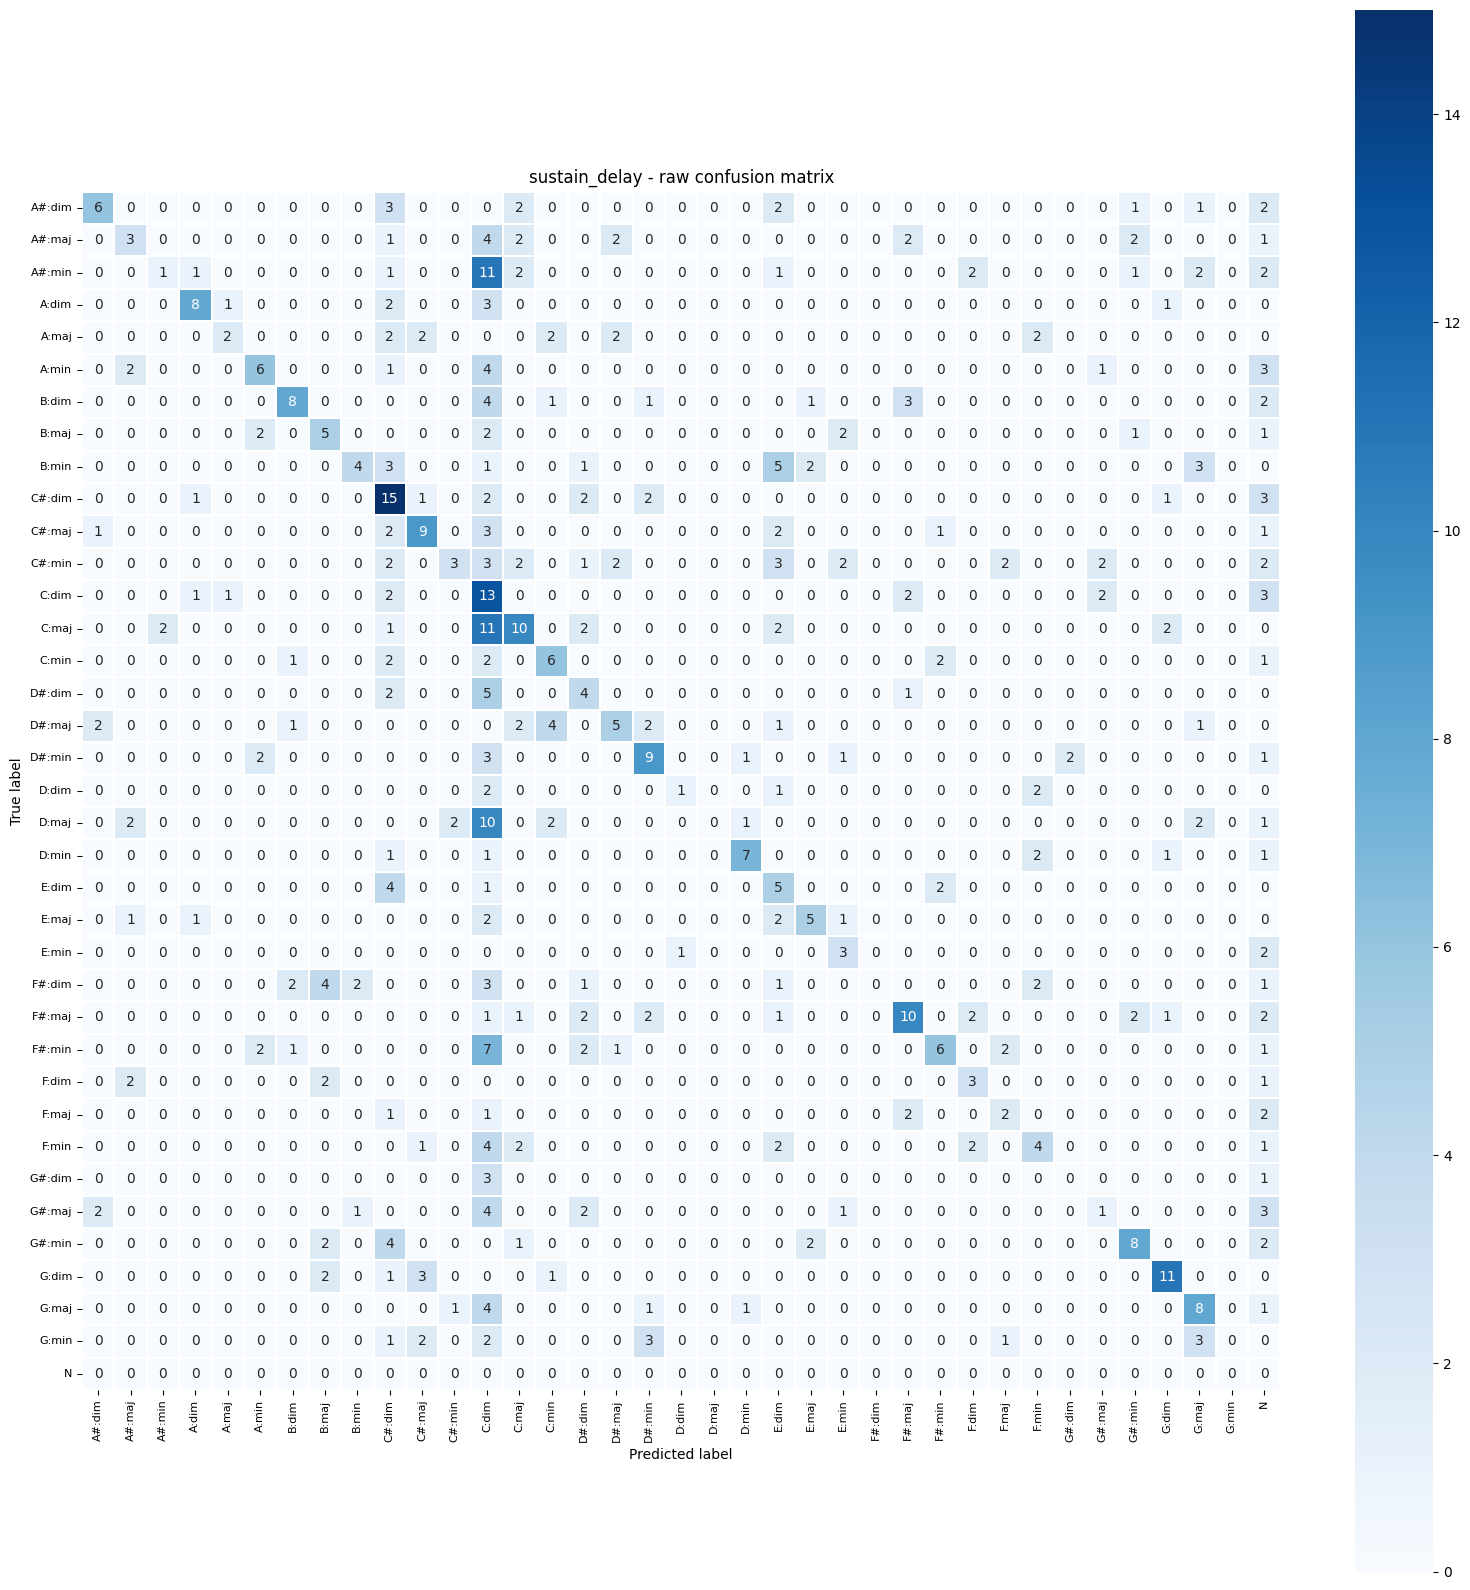

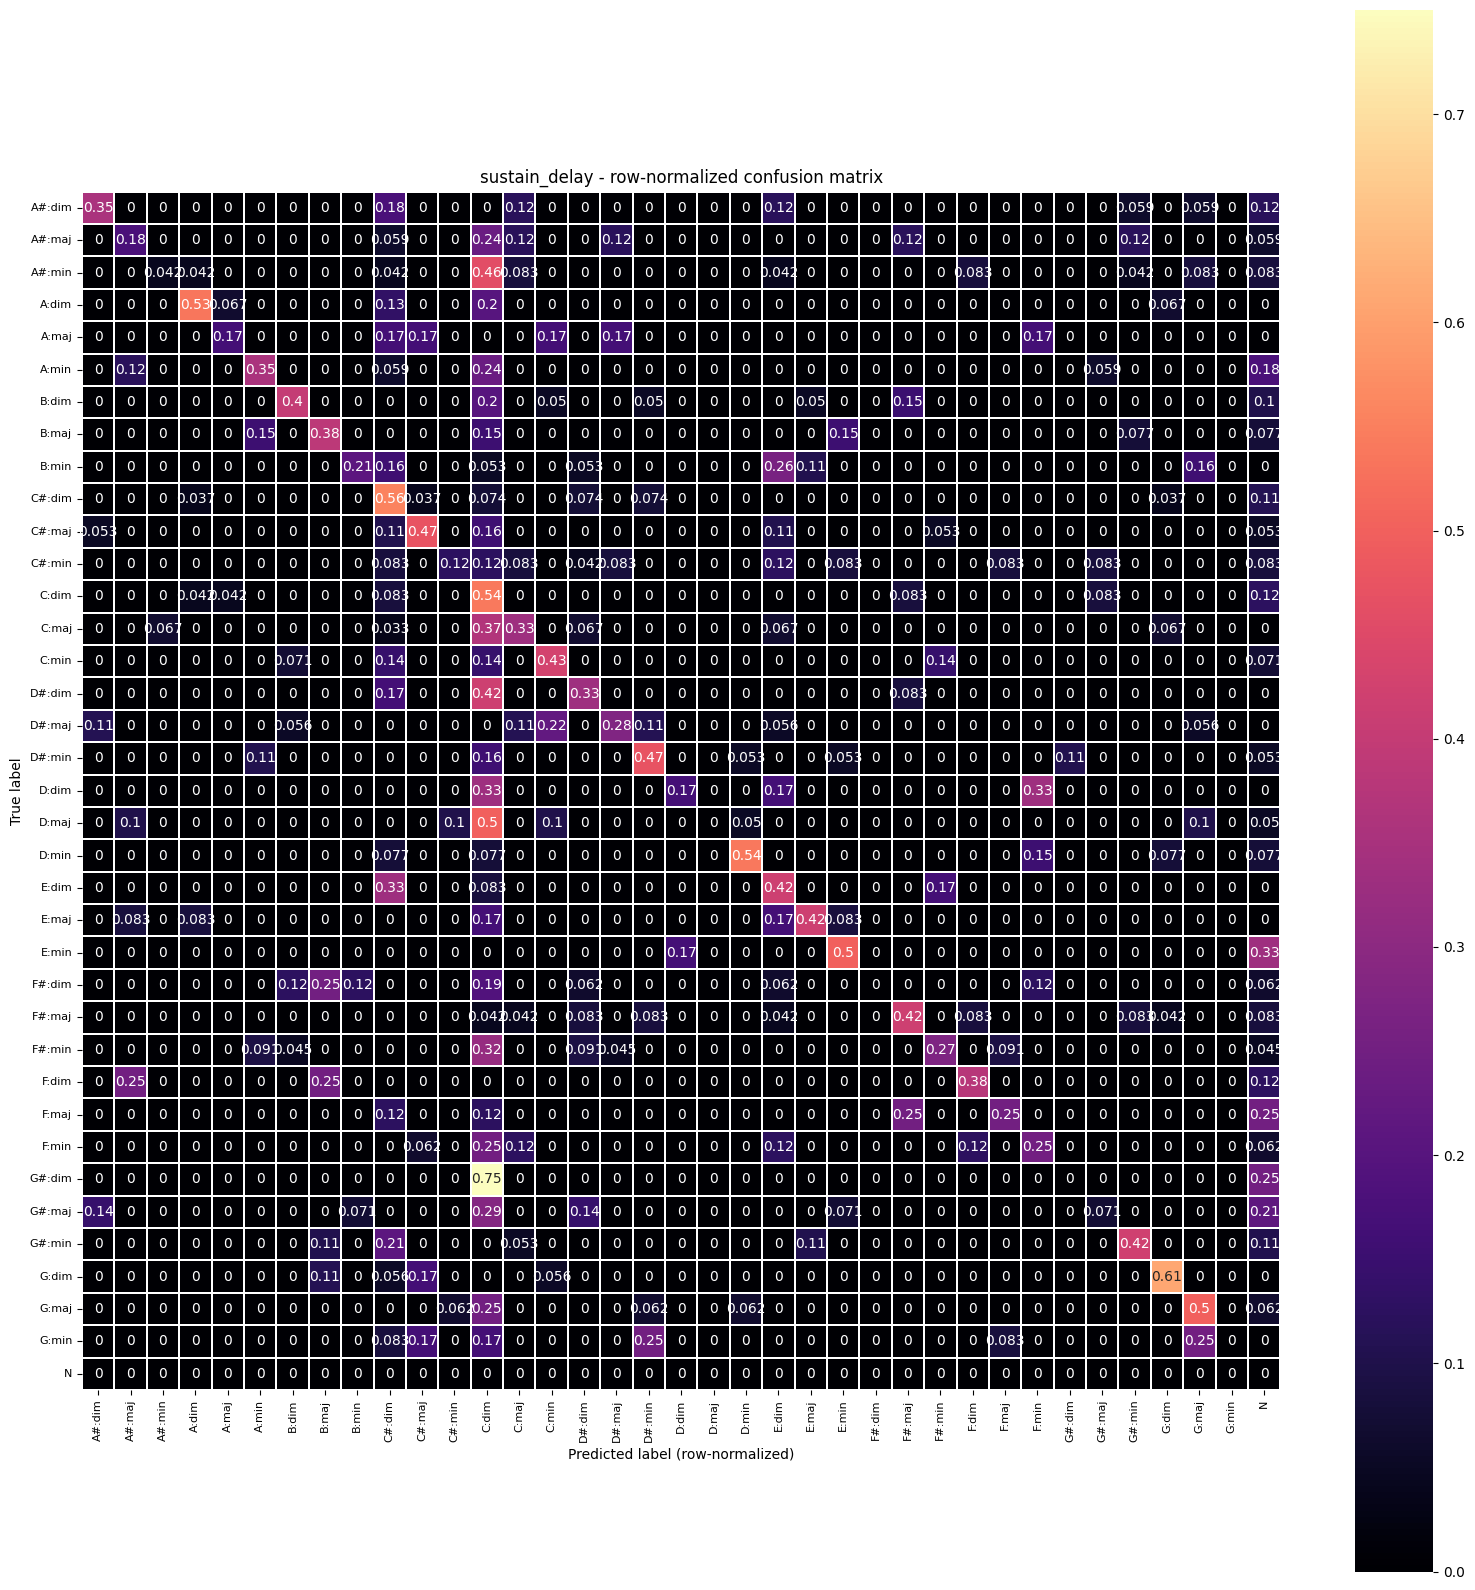

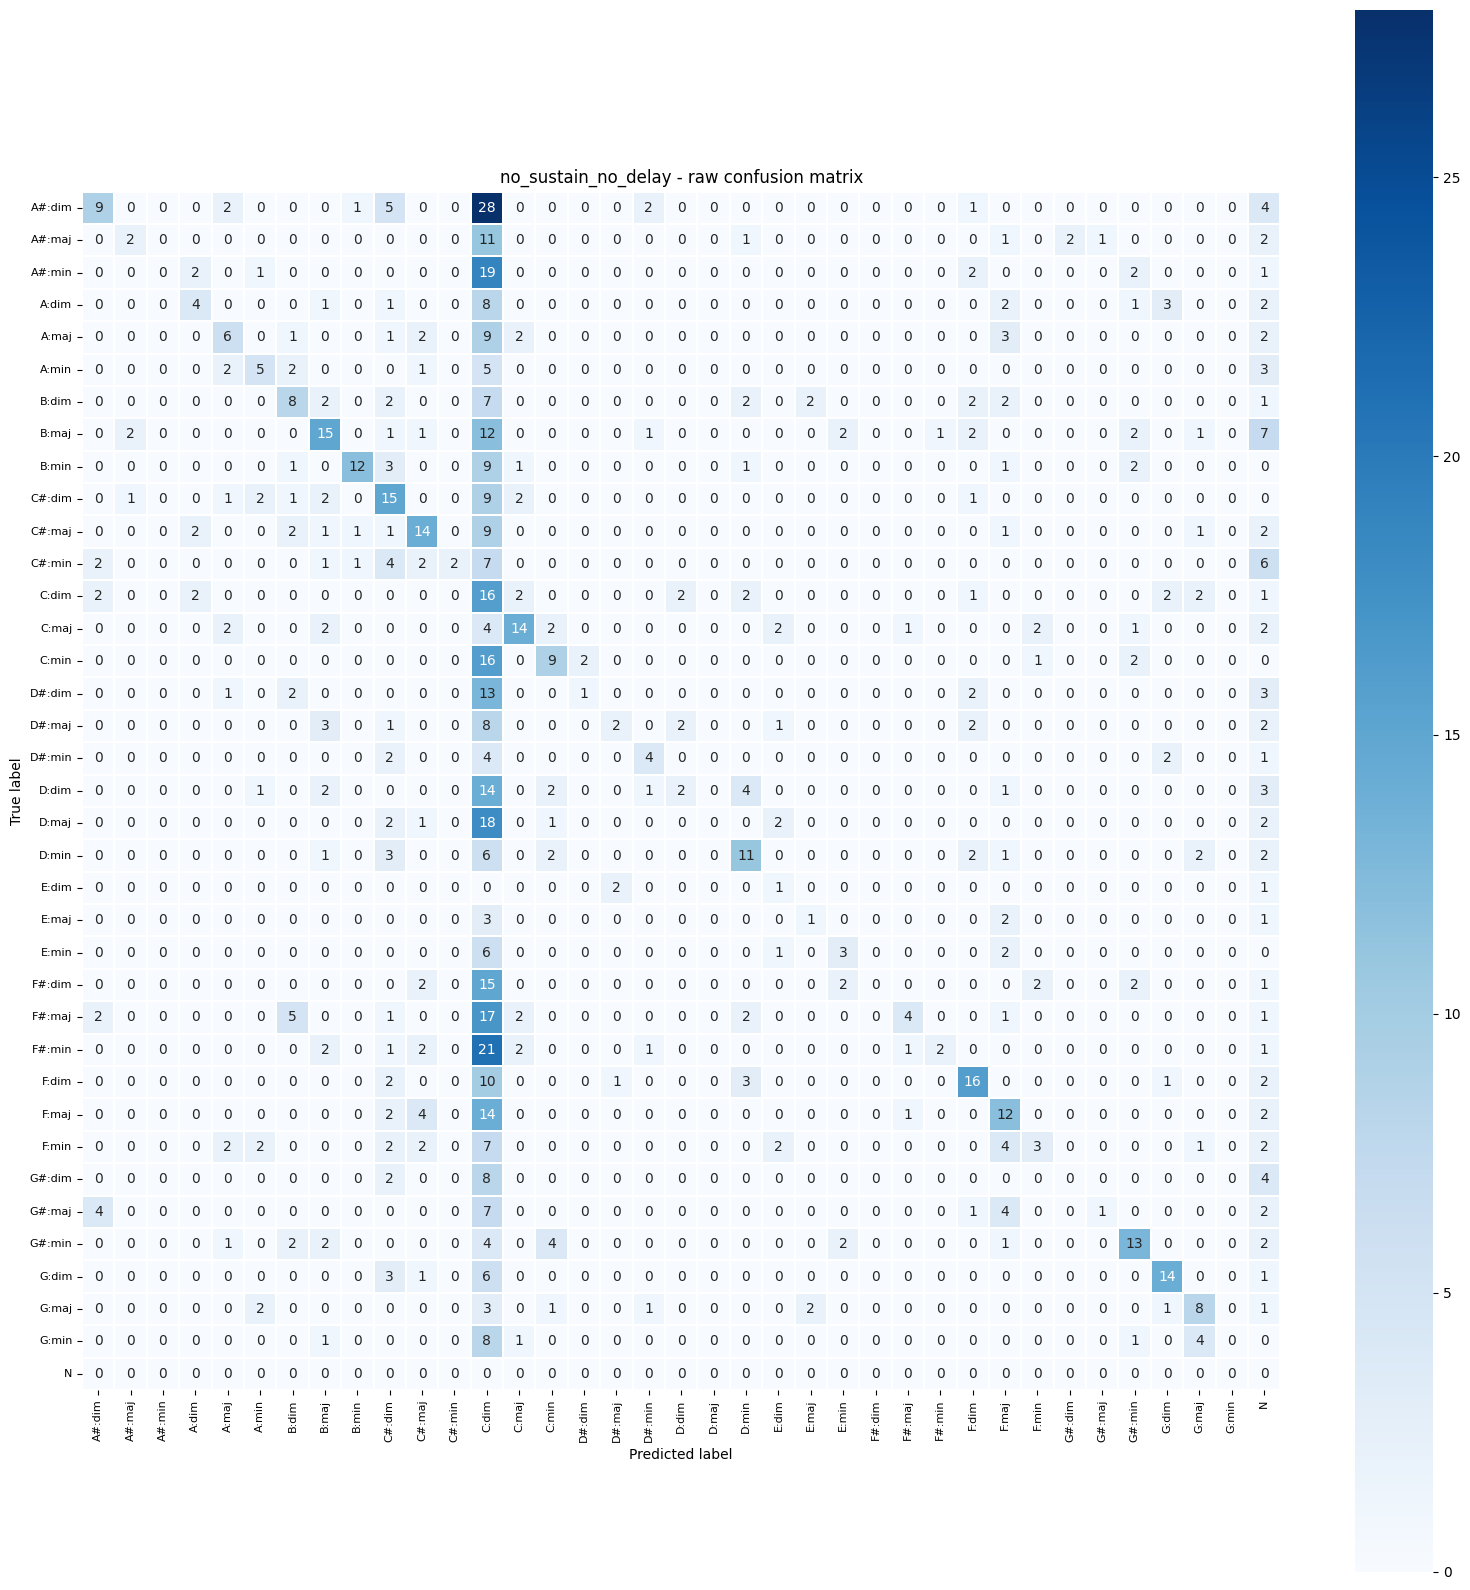

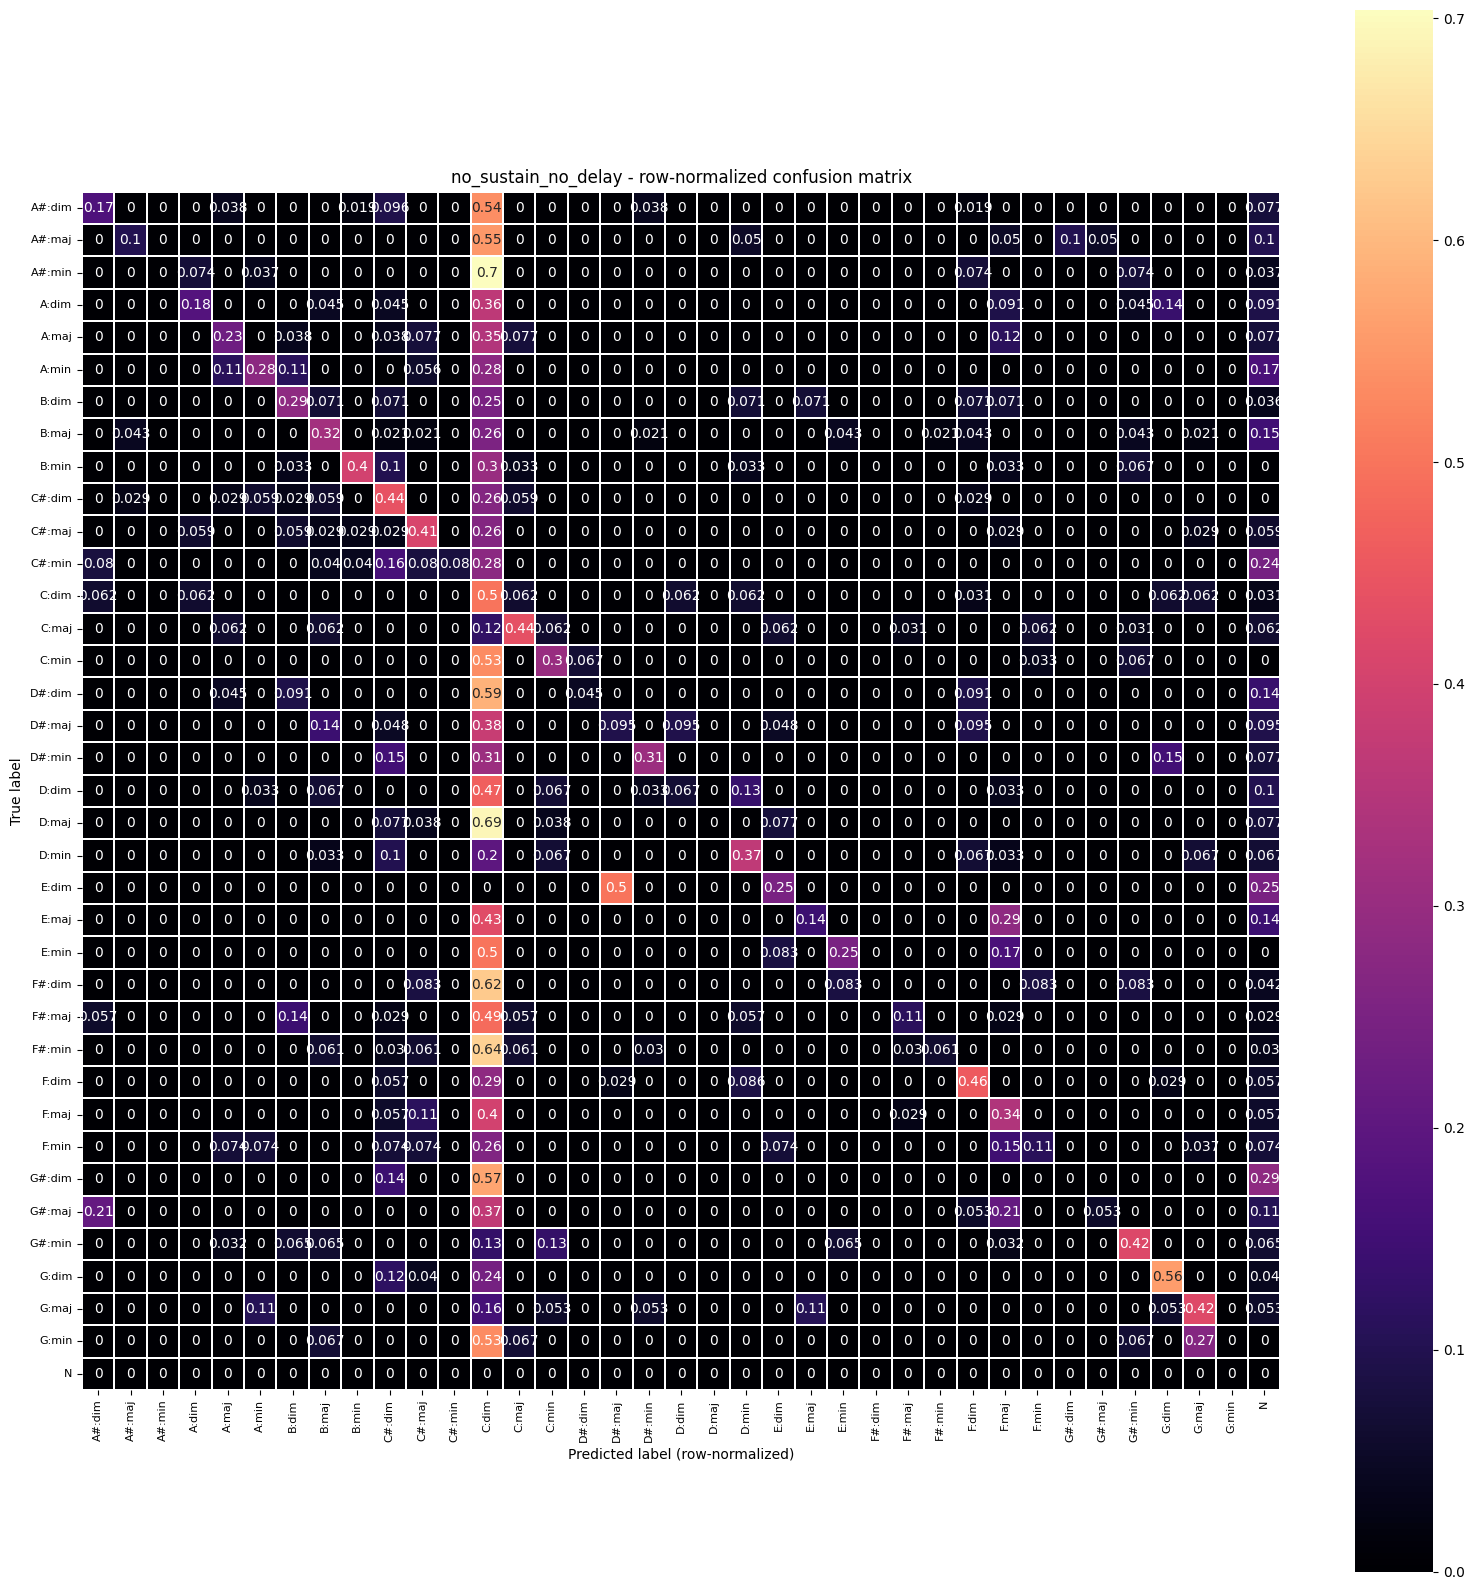

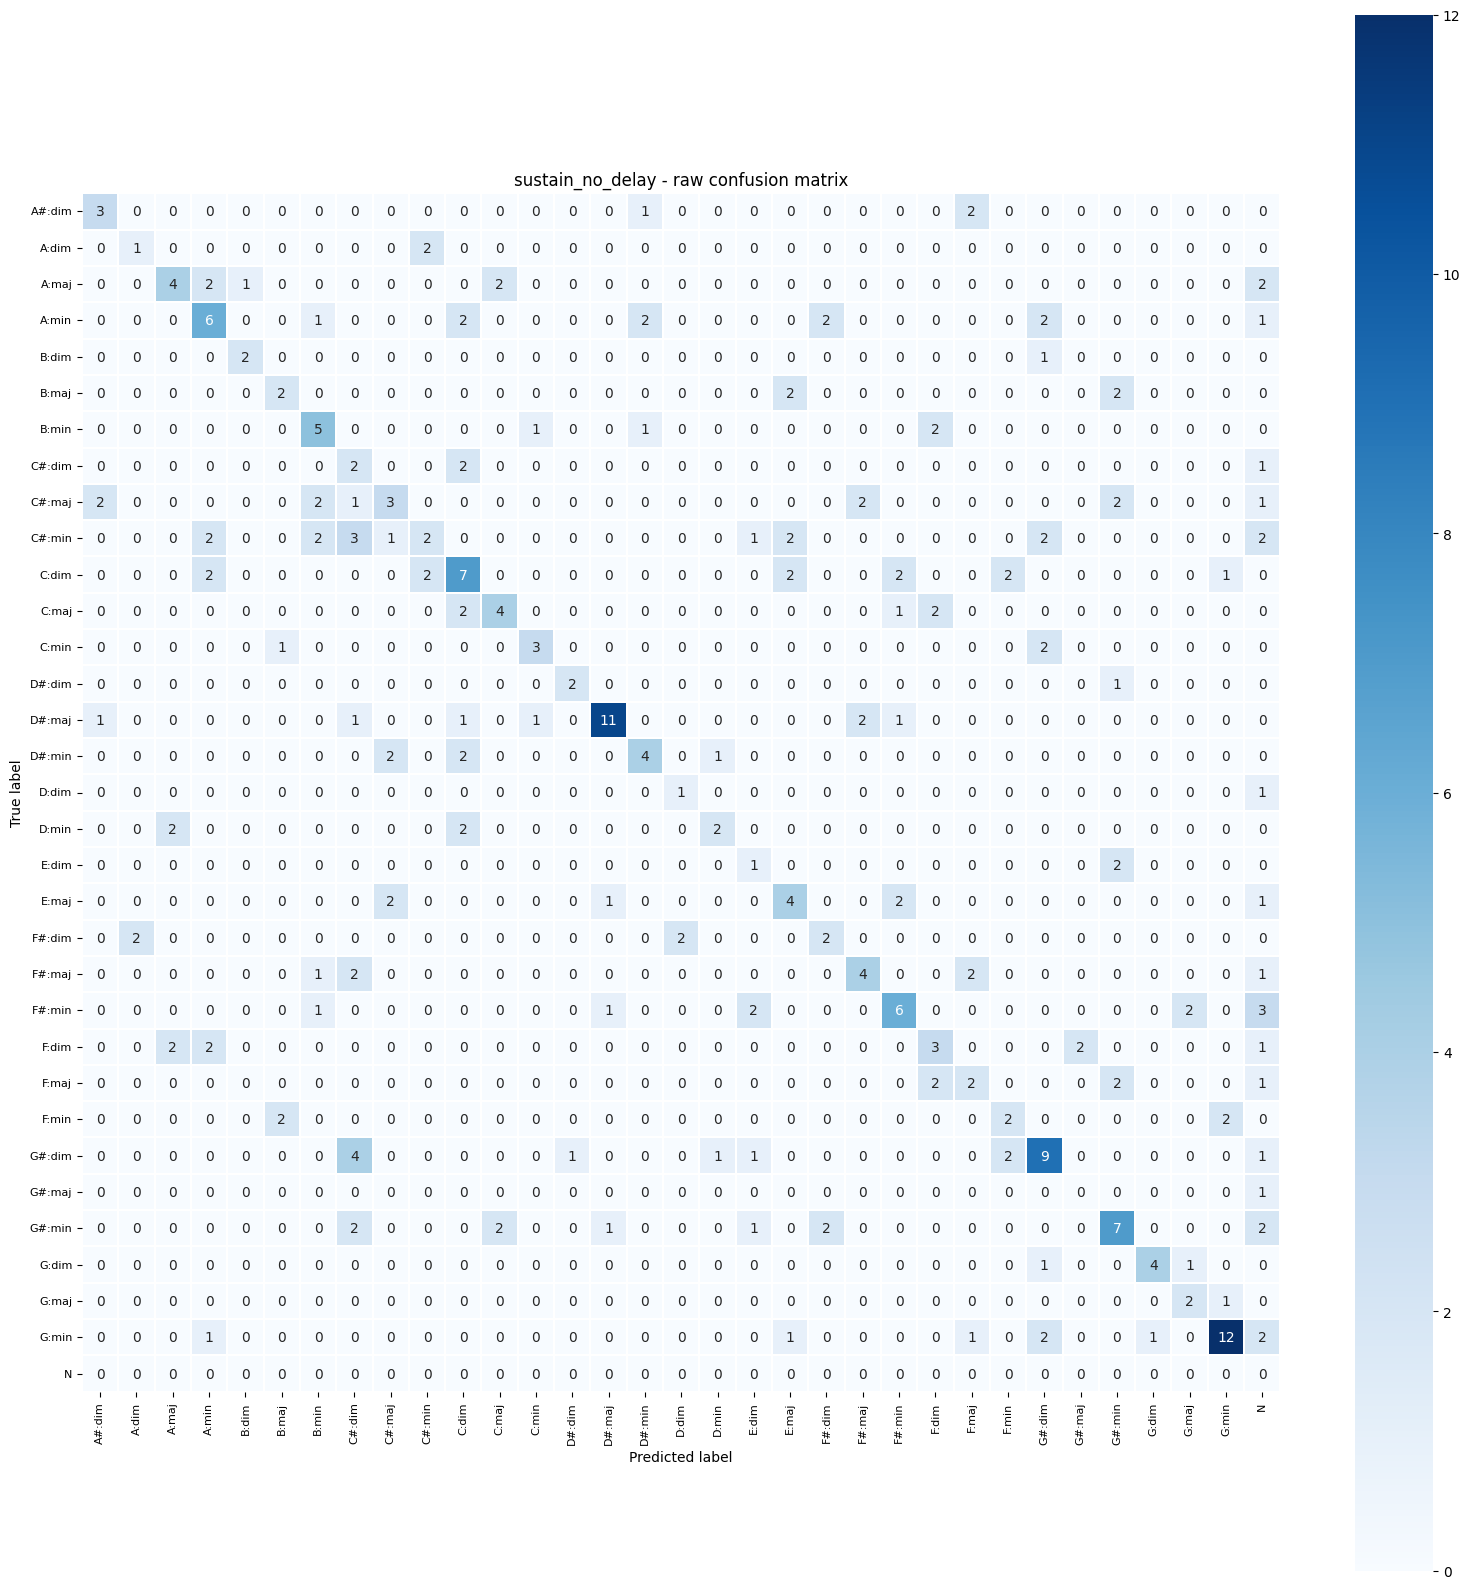

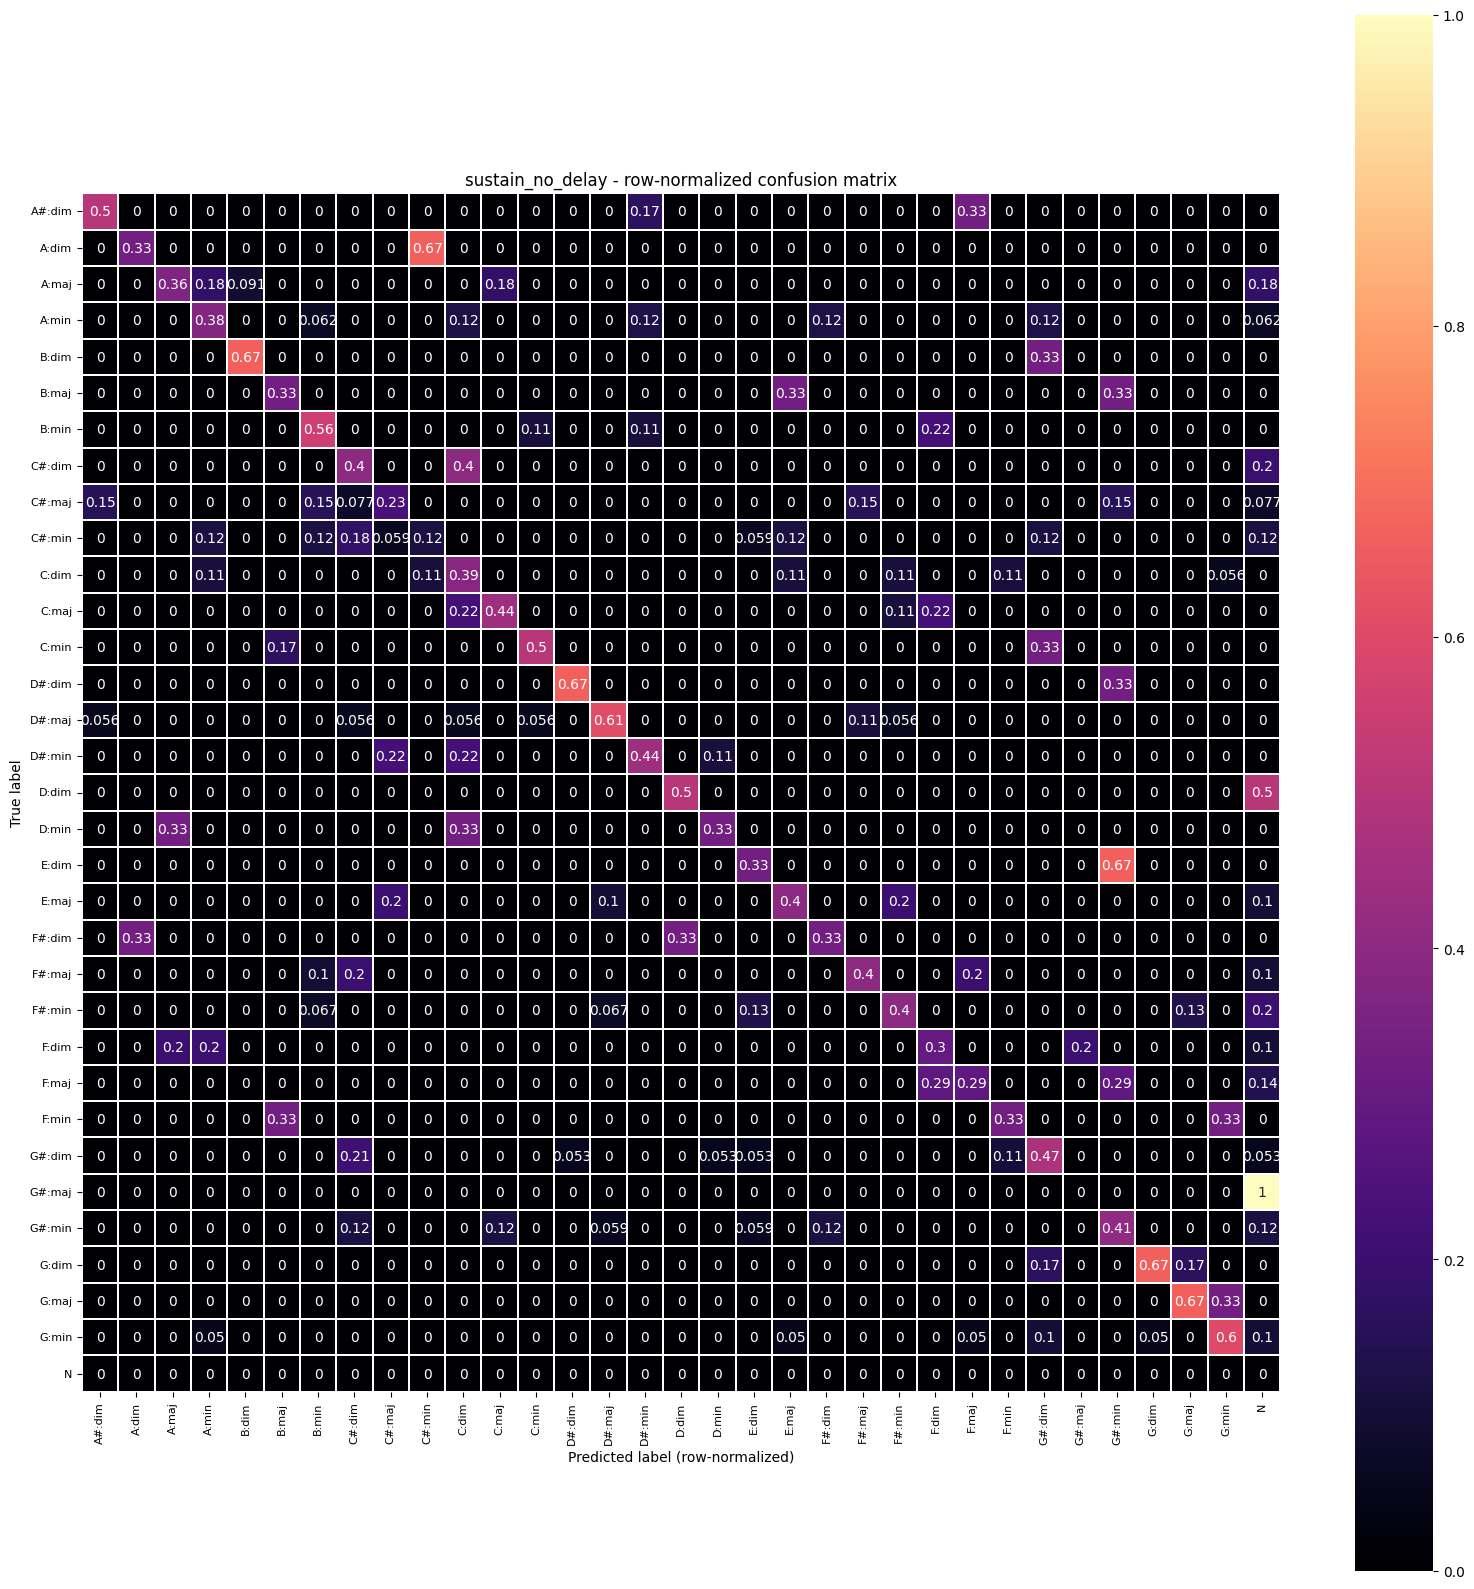

In [17]:
from sklearn.metrics import confusion_matrix

def collect_classification_sequences(dataset_name, parameters=ONSET_PARAMETERS):
    with load_validation_npz(dataset_name) as data:
        features = data['features']
        annotations = data['annotations']

        reference_labels = []
        estimated_labels = []
        interval_durations = []

        for sample_index, sample_cqt in enumerate(features):
            sample_prediction = build_estimated_annotations_for_sample(
                sample_cqt,
                parameters,
                dataset_name,
                sample_index,
            )
            sample_evaluation = evaluate_sample_annotations(
                annotations[sample_index],
                sample_prediction['estimated_intervals'],
                sample_prediction['estimated_labels'],
                dataset_name,
                sample_index,
            )

            reference_labels.extend(sample_evaluation['merged_reference_labels'])
            estimated_labels.extend(sample_evaluation['merged_estimated_labels'])
            interval_durations.extend(sample_evaluation['merged_durations'])

    return {
        'reference_labels': reference_labels,
        'estimated_labels': estimated_labels,
        'interval_durations': np.asarray(interval_durations, dtype=float),
    }

def build_confusion_tables(reference_labels, estimated_labels, interval_durations):
    label_order = sorted(set(reference_labels).union(set(estimated_labels)))
    raw_matrix = confusion_matrix(reference_labels, estimated_labels, labels=label_order)
    weighted_matrix = confusion_matrix(
        reference_labels,
        estimated_labels,
        labels=label_order,
        sample_weight=interval_durations,
    )

    row_totals = raw_matrix.sum(axis=1, keepdims=True)
    normalized_matrix = np.divide(
        raw_matrix.astype(float),
        row_totals,
        out=np.zeros_like(raw_matrix, dtype=float),
        where=row_totals != 0,
    )

    raw_df = pd.DataFrame(raw_matrix, index=label_order, columns=label_order)
    normalized_df = pd.DataFrame(normalized_matrix, index=label_order, columns=label_order)
    weighted_df = pd.DataFrame(weighted_matrix, index=label_order, columns=label_order)

    off_diagonal = []
    for true_label in label_order:
        for predicted_label in label_order:
            if true_label == predicted_label:
                continue
            count = int(raw_df.loc[true_label, predicted_label])
            weight = float(weighted_df.loc[true_label, predicted_label])
            if count == 0 and weight == 0.0:
                continue
            off_diagonal.append({
                'true_label': true_label,
                'predicted_label': predicted_label,
                'count': count,
                'weighted_duration': weight,
                'row_normalized_rate': float(normalized_df.loc[true_label, predicted_label]),
            })

    top_misclassifications_df = pd.DataFrame(off_diagonal)
    if not top_misclassifications_df.empty:
        top_misclassifications_df = top_misclassifications_df.sort_values(
            ['count', 'weighted_duration'], ascending=False
        )

    return {
        'labels': label_order,
        'raw': raw_df,
        'normalized': normalized_df,
        'weighted': weighted_df,
        'top_misclassifications': top_misclassifications_df,
    }

def plot_confusion_heatmap(matrix_df, title, *, normalize=False, figsize=None, cmap='Blues'):
    if figsize is None:
        size = max(8, min(0.45 * len(matrix_df.columns) + 4, 16))
        figsize = (size, size)

    figure, axis = plt.subplots(figsize=figsize)
    sns.heatmap(
        matrix_df,
        ax=axis,
        cmap=cmap,
        square=True,
        cbar=True,
        annot=True,
        linewidths=0.15,
        linecolor='white',
        xticklabels=matrix_df.columns,
        yticklabels=matrix_df.index,
    )
    axis.set_title(title)
    axis.set_xlabel('Predicted label')
    axis.set_ylabel('True label')
    axis.tick_params(axis='x', labelrotation=90, labelsize=8)
    axis.tick_params(axis='y', labelrotation=0, labelsize=8)

    if normalize:
        axis.set_xlabel('Predicted label (row-normalized)')

    figure.tight_layout()
    return figure

classification_confusion_tables = {}

for dataset_name in VALIDATION_DATASETS:
    print(f'Classification confusion matrices: {dataset_name}')
    sequences = collect_classification_sequences(dataset_name)
    confusion_tables = build_confusion_tables(
        sequences['reference_labels'],
        sequences['estimated_labels'],
        sequences['interval_durations'],
    )
    classification_confusion_tables[dataset_name] = confusion_tables

    display(plot_confusion_heatmap(confusion_tables['raw'], f'{dataset_name} - raw confusion matrix'))
    display(plot_confusion_heatmap(confusion_tables['normalized'], f'{dataset_name} - row-normalized confusion matrix', normalize=True, cmap='magma'))
    display(confusion_tables['top_misclassifications'].head(25).round(4))